In [1]:
from __future__ import annotations

import json
import os
import pickle
from dataclasses import asdict, dataclass, replace
from pathlib import Path
from typing import Any, Optional

import albumentations as A
import cv2
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import tensorflow as tf
from sklearn.model_selection import train_test_split
from tensorflow.keras.applications.resnet50 import ResNet50, preprocess_input
from tensorflow.keras.callbacks import BackupAndRestore, EarlyStopping, ModelCheckpoint, ReduceLROnPlateau
from tensorflow.keras.layers import Activation, BatchNormalization, Concatenate, Conv2D, UpSampling2D
from tensorflow.keras.models import Model, load_model, model_from_json

PROJECT_ROOT = Path.cwd()
DEFAULT_ARTIFACTS_DIR = PROJECT_ROOT / "models"
DEFAULT_CHECKPOINT_DIR = DEFAULT_ARTIFACTS_DIR / "checkpoints"
DEFAULT_FINAL_MODEL_PKL_PATH = PROJECT_ROOT / "best_resnet50_cloud_segmentation.pkl"
DEFAULT_FINAL_MODEL_KERAS_PATH = PROJECT_ROOT / "best_resnet50_cloud_segmentation.keras"
DEFAULT_THRESHOLDS_PATH = DEFAULT_ARTIFACTS_DIR / "best_thresholds.json"
DEFAULT_METRICS_PATH = DEFAULT_ARTIFACTS_DIR / "final_metrics.json"
DEFAULT_TRAINING_STATE_PATH = DEFAULT_CHECKPOINT_DIR / "training_state.json"

KAGGLE_API_TOKEN = "KGAT_040f033cb5072df087dbe0fdfd60966f"


@dataclass
class PipelineConfig:
    seed: int = 42
    image_size: int = 224
    orig_height: int = 1400
    orig_width: int = 2100
    batch_size: int = 8
    epochs_stage1: int = 30
    epochs_stage2: int = 30
    max_images: Optional[int] = 1200
    fine_tune_last_layers: int = 40
    learning_rate_stage1: float = 1e-3
    learning_rate_stage2: float = 1e-4
    auto_tune: bool = False
    tuning_trials: int = 3
    tuning_train_samples: int = 256
    tuning_val_samples: int = 64
    evaluation_batches: Optional[int] = 12
    object_iou_threshold: float = 0.5
    classes: tuple[str, ...] = ("Fish", "Flower", "Gravel", "Sugar")


def _optional_int(value: str | None, default: Optional[int]) -> Optional[int]:
    if value is None or value == "":
        return default
    return int(value)


def get_runtime_config() -> PipelineConfig:
    return PipelineConfig(
        seed=int(os.getenv("SEED", "42")),
        image_size=int(os.getenv("IMG_SIZE", "224")),
        batch_size=int(os.getenv("BATCH_SIZE", "8")),
        epochs_stage1=int(os.getenv("EPOCHS_STAGE1", "30")),
        epochs_stage2=int(os.getenv("EPOCHS_STAGE2", "30")),
        max_images=_optional_int(os.getenv("MAX_IMAGES"), 1200),
        fine_tune_last_layers=int(os.getenv("FINE_TUNE_LAST_LAYERS", "40")),
        learning_rate_stage1=float(os.getenv("LR_STAGE1", "1e-3")),
        learning_rate_stage2=float(os.getenv("LR_STAGE2", "1e-4")),
        auto_tune=os.getenv("AUTO_TUNE", "0") == "1",
        tuning_trials=int(os.getenv("TUNING_TRIALS", "3")),
        tuning_train_samples=int(os.getenv("TUNING_TRAIN_SAMPLES", "256")),
        tuning_val_samples=int(os.getenv("TUNING_VAL_SAMPLES", "64")),
        evaluation_batches=_optional_int(os.getenv("EVAL_BATCHES"), 12),
        object_iou_threshold=float(os.getenv("OBJECT_IOU_THRESHOLD", "0.5")),
    )


def set_seed(seed: int) -> None:
    np.random.seed(seed)
    tf.random.set_seed(seed)


def enable_mixed_precision_if_available() -> None:
    if tf.config.list_physical_devices("GPU"):
        try:
            from tensorflow.keras import mixed_precision

            mixed_precision.set_global_policy("mixed_float16")
        except Exception:
            pass


def resolve_dataset_paths(data_root: str | Path) -> tuple[Path, Path]:
    root = Path(data_root)
    train_csv = root / "train.csv"
    train_img_dir = root / "train_images"

    if train_csv.exists() and train_img_dir.exists():
        return train_csv, train_img_dir

    for candidate in root.rglob("train.csv"):
        train_csv = candidate
        break

    for candidate in root.rglob("train_images"):
        train_img_dir = candidate
        break

    if not train_csv.exists():
        raise FileNotFoundError("No se encontró train.csv en el directorio del dataset.")
    if not train_img_dir.exists():
        raise FileNotFoundError("No se encontró la carpeta train_images en el directorio del dataset.")

    return train_csv, train_img_dir


def download_competition_data() -> Path:
    if not os.getenv("KAGGLE_API_TOKEN"):
        raise EnvironmentError("Define KAGGLE_API_TOKEN antes de descargar con Kaggle.")

    try:
        import kagglehub
    except ImportError as exc:
        raise ImportError("kagglehub no está instalado. Define CLOUD_DATA_ROOT o instala kagglehub.") from exc

    return Path(kagglehub.competition_download("understanding_cloud_organization"))

I0000 00:00:1779824529.463011    9953 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1779824532.110656    9953 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.


## Paso 2: datos, preprocesamiento y generadores

En este bloque se cargan las anotaciones, se reconstruyen las máscaras desde RLE y se arma el `Sequence` que alimenta el entrenamiento.

In [2]:
def load_annotations(train_csv: Path, classes: tuple[str, ...]) -> pd.DataFrame:
    df = pd.read_csv(train_csv)
    df[["ImageId", "Class"]] = df["Image_Label"].str.rsplit("_", n=1, expand=True)
    mask_df = df.pivot(index="ImageId", columns="Class", values="EncodedPixels")
    return mask_df.reindex(columns=list(classes))


def rle_decode(mask_rle: Any, shape: tuple[int, int]) -> np.ndarray:
    if pd.isna(mask_rle):
        return np.zeros(shape, dtype=np.uint8)

    parts = str(mask_rle).split()
    starts = np.asarray(parts[0::2], dtype=np.int64) - 1
    lengths = np.asarray(parts[1::2], dtype=np.int64)
    ends = starts + lengths

    mask = np.zeros(shape[0] * shape[1], dtype=np.uint8)
    for start, end in zip(starts, ends):
        mask[start:end] = 1

    return mask.reshape((shape[1], shape[0])).T


def load_image(image_path: str | Path, image_size: int) -> np.ndarray:
    image = cv2.imread(str(image_path))
    if image is None:
        raise FileNotFoundError(f"No se pudo leer la imagen: {image_path}")
    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
    image = cv2.resize(image, (image_size, image_size))
    return image


def load_mask(image_id: str, mask_df: pd.DataFrame, config: PipelineConfig) -> np.ndarray:
    mask = np.zeros((config.orig_height, config.orig_width, len(config.classes)), dtype=np.uint8)
    for index, cls in enumerate(config.classes):
        encoded_pixels = mask_df.loc[image_id, cls]
        if isinstance(encoded_pixels, str):
            mask[:, :, index] = rle_decode(encoded_pixels, (config.orig_height, config.orig_width))
    return cv2.resize(mask, (config.image_size, config.image_size), interpolation=cv2.INTER_NEAREST)


def normalize_image_ids(image_ids: list[str], config: PipelineConfig) -> list[str]:
    ids = np.array(image_ids)
    rng = np.random.default_rng(config.seed)
    rng.shuffle(ids)
    if config.max_images is not None:
        ids = ids[: config.max_images]
    return ids.tolist()


class CloudSequence(tf.keras.utils.Sequence):
    def __init__(
        self,
        image_ids: list[str],
        train_img_dir: Path,
        mask_df: pd.DataFrame,
        config: PipelineConfig,
        augment: bool = False,
        shuffle: bool = True,
    ):
        self.image_ids = np.array(image_ids)
        self.train_img_dir = train_img_dir
        self.mask_df = mask_df
        self.config = config
        self.batch_size = config.batch_size
        self.augment = augment
        self.shuffle = shuffle
        self.on_epoch_end()

        self.aug = None
        if self.augment:
            self.aug = A.Compose(
                [
                    A.HorizontalFlip(p=0.5),
                    A.VerticalFlip(p=0.2),
                    A.RandomRotate90(p=0.3),
                    A.ShiftScaleRotate(shift_limit=0.0625, scale_limit=0.1, rotate_limit=15, p=0.4),
                    A.RandomBrightnessContrast(p=0.4),
                ]
            )

    def __len__(self) -> int:
        return int(np.ceil(len(self.image_ids) / self.batch_size))

    def on_epoch_end(self) -> None:
        if self.shuffle:
            np.random.shuffle(self.image_ids)

    def __getitem__(self, idx: int) -> tuple[np.ndarray, np.ndarray]:
        batch_ids = self.image_ids[idx * self.batch_size : (idx + 1) * self.batch_size]
        x_batch = np.zeros((len(batch_ids), self.config.image_size, self.config.image_size, 3), dtype=np.float32)
        y_batch = np.zeros((len(batch_ids), self.config.image_size, self.config.image_size, len(self.config.classes)), dtype=np.float32)

        for batch_index, image_id in enumerate(batch_ids):
            img_path = self.train_img_dir / image_id
            image = load_image(img_path, self.config.image_size)
            mask = load_mask(image_id, self.mask_df, self.config)

            if self.aug is not None:
                augmented = self.aug(image=image, mask=mask)
                image = augmented["image"]
                mask = augmented["mask"]

            x_batch[batch_index] = preprocess_input(image.astype(np.float32))
            y_batch[batch_index] = mask.astype(np.float32)

        return x_batch, y_batch


def build_dataset_splits(data_root: str | Path, config: PipelineConfig) -> tuple[Path, Path, pd.DataFrame, list[str], list[str]]:
    train_csv, train_img_dir = resolve_dataset_paths(data_root)
    mask_df = load_annotations(train_csv, config.classes)
    image_ids = normalize_image_ids(mask_df.index.tolist(), config)
    train_ids, val_ids = train_test_split(image_ids, test_size=0.2, random_state=config.seed)
    return train_csv, train_img_dir, mask_df, train_ids, val_ids


def build_generators(
    train_ids: list[str],
    val_ids: list[str],
    train_img_dir: Path,
    mask_df: pd.DataFrame,
    config: PipelineConfig,
) -> tuple[CloudSequence, CloudSequence]:
    train_gen = CloudSequence(train_ids, train_img_dir, mask_df, config, augment=True, shuffle=True)
    val_gen = CloudSequence(val_ids, train_img_dir, mask_df, config, augment=False, shuffle=False)
    return train_gen, val_gen

## Paso 3: métricas de segmentación y detección

Aquí se calculan `dice`, `IoU`, precisión, recall y F1 a nivel de píxel, y además métricas de detección de objetos derivadas de componentes conectados: precisión, recall, F1, AP50 e IoU medio.

In [3]:
def dice_coef(y_true, y_pred, smooth: float = 1e-6):
    y_true_f = tf.reshape(y_true, [-1])
    y_pred_f = tf.reshape(y_pred, [-1])
    intersection = tf.reduce_sum(y_true_f * y_pred_f)
    return (2.0 * intersection + smooth) / (tf.reduce_sum(y_true_f) + tf.reduce_sum(y_pred_f) + smooth)


def iou_coef(y_true, y_pred, smooth: float = 1e-6):
    y_true_f = tf.reshape(y_true, [-1])
    y_pred_f = tf.reshape(y_pred, [-1])
    intersection = tf.reduce_sum(y_true_f * y_pred_f)
    union = tf.reduce_sum(y_true_f) + tf.reduce_sum(y_pred_f) - intersection
    return (intersection + smooth) / (union + smooth)


def pixel_precision(y_true, y_pred, threshold: float = 0.5):
    y_pred_bin = tf.cast(y_pred > threshold, tf.float32)
    y_true_bin = tf.cast(y_true > 0.5, tf.float32)
    tp = tf.reduce_sum(y_true_bin * y_pred_bin)
    fp = tf.reduce_sum((1.0 - y_true_bin) * y_pred_bin)
    return (tp + 1e-6) / (tp + fp + 1e-6)


def pixel_recall(y_true, y_pred, threshold: float = 0.5):
    y_pred_bin = tf.cast(y_pred > threshold, tf.float32)
    y_true_bin = tf.cast(y_true > 0.5, tf.float32)
    tp = tf.reduce_sum(y_true_bin * y_pred_bin)
    fn = tf.reduce_sum(y_true_bin * (1.0 - y_pred_bin))
    return (tp + 1e-6) / (tp + fn + 1e-6)


def pixel_f1(y_true, y_pred, threshold: float = 0.5):
    precision = pixel_precision(y_true, y_pred, threshold)
    recall = pixel_recall(y_true, y_pred, threshold)
    return (2.0 * precision * recall + 1e-6) / (precision + recall + 1e-6)


def tversky_index(y_true, y_pred, alpha: float = 0.5, beta: float = 0.5, smooth: float = 1e-6):
    y_true_f = tf.reshape(y_true, [-1])
    y_pred_f = tf.reshape(y_pred, [-1])
    tp = tf.reduce_sum(y_true_f * y_pred_f)
    fp = tf.reduce_sum((1 - y_true_f) * y_pred_f)
    fn = tf.reduce_sum(y_true_f * (1 - y_pred_f))
    return (tp + smooth) / (tp + alpha * fp + beta * fn + smooth)


def focal_tversky_loss(y_true, y_pred, alpha: float = 0.5, beta: float = 0.5, gamma: float = 0.75):
    tversky = tversky_index(y_true, y_pred, alpha, beta)
    return tf.pow((1 - tversky), gamma)


def focal_tversky_combined(y_true, y_pred):
    bce = tf.keras.losses.binary_crossentropy(y_true, y_pred)
    return tf.reduce_mean(bce) + focal_tversky_loss(y_true, y_pred)


def _binary_mask_components(mask: np.ndarray, score_map: Optional[np.ndarray] = None) -> list[dict[str, Any]]:
    mask_uint8 = mask.astype(np.uint8)
    num_labels, labels = cv2.connectedComponents(mask_uint8)
    components: list[dict[str, Any]] = []

    for label in range(1, num_labels):
        component_mask = labels == label
        if not np.any(component_mask):
            continue
        ys, xs = np.where(component_mask)
        score = float(score_map[component_mask].mean()) if score_map is not None and np.any(component_mask) else 1.0
        components.append(
            {
                "mask": component_mask,
                "score": score,
                "bbox": (int(xs.min()), int(ys.min()), int(xs.max()), int(ys.max())),
            }
        )

    return components


def _component_iou(mask_a: np.ndarray, mask_b: np.ndarray) -> float:
    intersection = np.logical_and(mask_a, mask_b).sum()
    union = np.logical_or(mask_a, mask_b).sum()
    if union == 0:
        return 0.0
    return float(intersection / union)


def _average_precision_from_detections(scores: list[float], labels: list[int], num_gt: int) -> float:
    if num_gt == 0 or not scores:
        return 0.0

    order = np.argsort(-np.asarray(scores))
    tp = np.asarray(labels, dtype=np.float32)[order]
    fp = 1.0 - tp
    tp_cum = np.cumsum(tp)
    fp_cum = np.cumsum(fp)
    recall = tp_cum / max(num_gt, 1)
    precision = tp_cum / np.maximum(tp_cum + fp_cum, 1e-6)

    mrec = np.concatenate([[0.0], recall, [1.0]])
    mpre = np.concatenate([[0.0], precision, [0.0]])
    for index in range(len(mpre) - 1, 0, -1):
        mpre[index - 1] = max(mpre[index - 1], mpre[index])

    changing_points = np.where(mrec[1:] != mrec[:-1])[0]
    ap = np.sum((mrec[changing_points + 1] - mrec[changing_points]) * mpre[changing_points + 1])
    return float(ap)


def evaluate_object_detection_metrics(
    model: Model,
    val_gen: CloudSequence,
    thresholds: list[float],
    config: PipelineConfig,
    max_batches: Optional[int] = None,
) -> dict[str, float]:
    total_batches = len(val_gen) if max_batches is None else min(len(val_gen), max_batches)
    class_scores: dict[str, list[float]] = {cls: [] for cls in config.classes}
    class_labels: dict[str, list[int]] = {cls: [] for cls in config.classes}
    class_gt_counts: dict[str, int] = {cls: 0 for cls in config.classes}
    class_tp_counts: dict[str, int] = {cls: 0 for cls in config.classes}
    class_pred_counts: dict[str, int] = {cls: 0 for cls in config.classes}
    class_matched_ious: dict[str, list[float]] = {cls: [] for cls in config.classes}

    for batch_index in range(total_batches):
        x_batch, y_batch = val_gen[batch_index]
        y_pred_batch = model.predict(x_batch, verbose=0)

        for sample_index in range(y_batch.shape[0]):
            for class_index, class_name in enumerate(config.classes):
                y_true_mask = y_batch[sample_index, :, :, class_index] > 0.5
                y_pred_prob = y_pred_batch[sample_index, :, :, class_index]
                y_pred_mask = y_pred_prob > thresholds[class_index]

                gt_components = _binary_mask_components(y_true_mask)
                pred_components = _binary_mask_components(y_pred_mask, score_map=y_pred_prob)
                class_gt_counts[class_name] += len(gt_components)
                class_pred_counts[class_name] += len(pred_components)

                matched_gt: set[int] = set()
                for pred_component in sorted(pred_components, key=lambda item: item["score"], reverse=True):
                    best_iou = 0.0
                    best_gt_index = -1
                    for gt_index, gt_component in enumerate(gt_components):
                        if gt_index in matched_gt:
                            continue
                        iou = _component_iou(pred_component["mask"], gt_component["mask"])
                        if iou > best_iou:
                            best_iou = iou
                            best_gt_index = gt_index

                    is_tp = int(best_iou >= config.object_iou_threshold)
                    if is_tp and best_gt_index >= 0:
                        matched_gt.add(best_gt_index)
                        class_tp_counts[class_name] += 1
                        class_matched_ious[class_name].append(best_iou)

                    class_scores[class_name].append(pred_component["score"])
                    class_labels[class_name].append(is_tp)

    report: dict[str, float] = {}
    precision_values = []
    recall_values = []
    f1_values = []
    ap_values = []
    iou_values = []

    for class_name in config.classes:
        tp = class_tp_counts[class_name]
        fp = class_pred_counts[class_name] - tp
        fn = class_gt_counts[class_name] - tp
        precision = tp / max(tp + fp, 1)
        recall = tp / max(tp + fn, 1)
        f1 = (2.0 * precision * recall) / max(precision + recall, 1e-6)
        ap50 = _average_precision_from_detections(class_scores[class_name], class_labels[class_name], class_gt_counts[class_name])
        mean_iou = float(np.mean(class_matched_ious[class_name])) if class_matched_ious[class_name] else 0.0

        prefix = class_name.lower()
        report[f"det_precision_{prefix}"] = float(precision)
        report[f"det_recall_{prefix}"] = float(recall)
        report[f"det_f1_{prefix}"] = float(f1)
        report[f"det_ap50_{prefix}"] = float(ap50)
        report[f"det_mean_iou_{prefix}"] = float(mean_iou)

        precision_values.append(precision)
        recall_values.append(recall)
        f1_values.append(f1)
        ap_values.append(ap50)
        iou_values.append(mean_iou)

    report["det_precision"] = float(np.mean(precision_values)) if precision_values else 0.0
    report["det_recall"] = float(np.mean(recall_values)) if recall_values else 0.0
    report["det_f1"] = float(np.mean(f1_values)) if f1_values else 0.0
    report["det_ap50"] = float(np.mean(ap_values)) if ap_values else 0.0
    report["det_mean_iou"] = float(np.mean(iou_values)) if iou_values else 0.0
    return report

## Paso 4: modelo, checkpoints y guardado final

Este bloque construye la arquitectura, compila por etapas, guarda checkpoints por fase y deja el modelo final serializado en `.pkl` además de la compatibilidad `.keras`.

In [4]:
def conv_block(x, filters: int):
    x = Conv2D(filters, 3, padding="same")(x)
    x = BatchNormalization()(x)
    x = Activation("relu")(x)
    x = Conv2D(filters, 3, padding="same")(x)
    x = BatchNormalization()(x)
    x = Activation("relu")(x)
    return x


def up_block(x, skip, filters: int):
    x = UpSampling2D((2, 2), interpolation="bilinear")(x)
    x = Concatenate()([x, skip])
    return conv_block(x, filters)


def build_model(config: PipelineConfig) -> tuple[Model, Model]:
    base = ResNet50(weights="imagenet", include_top=False, input_shape=(config.image_size, config.image_size, 3))

    s1 = base.get_layer("conv1_relu").output
    s2 = base.get_layer("conv2_block3_out").output
    s3 = base.get_layer("conv3_block4_out").output
    s4 = base.get_layer("conv4_block6_out").output
    bottleneck = base.get_layer("conv5_block3_out").output

    x = up_block(bottleneck, s4, 512)
    x = up_block(x, s3, 256)
    x = up_block(x, s2, 128)
    x = up_block(x, s1, 64)
    x = UpSampling2D((2, 2), interpolation="bilinear")(x)
    x = conv_block(x, 32)
    outputs = Conv2D(len(config.classes), 1, activation="sigmoid", dtype="float32")(x)

    model = Model(inputs=base.input, outputs=outputs)
    return model, base


def compile_model(
    model: Model,
    base: Model,
    fine_tune: bool,
    learning_rate: float,
    fine_tune_last_layers: int,
) -> None:
    base.trainable = fine_tune
    if fine_tune:
        for layer in base.layers[:-fine_tune_last_layers]:
            layer.trainable = False

    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=learning_rate),
        loss=focal_tversky_combined,
        metrics=[dice_coef, iou_coef, pixel_precision, pixel_recall, pixel_f1],
    )


def save_metrics_report(metrics: dict[str, Any], path: Path = DEFAULT_METRICS_PATH) -> None:
    path.parent.mkdir(parents=True, exist_ok=True)
    with path.open("w", encoding="utf-8") as handle:
        json.dump(metrics, handle, indent=2)


def save_thresholds(thresholds: list[float], path: Path = DEFAULT_THRESHOLDS_PATH) -> None:
    path.parent.mkdir(parents=True, exist_ok=True)
    with path.open("w", encoding="utf-8") as handle:
        json.dump(thresholds, handle, indent=2)


def load_thresholds(path: Path = DEFAULT_THRESHOLDS_PATH, default: Optional[list[float]] = None) -> list[float]:
    if path.exists():
        with path.open("r", encoding="utf-8") as handle:
            return [float(value) for value in json.load(handle)]
    return default if default is not None else [0.5, 0.5, 0.5, 0.5]


def save_training_state(state_path: Path, state: dict[str, Any]) -> None:
    state_path.parent.mkdir(parents=True, exist_ok=True)
    with state_path.open("w", encoding="utf-8") as handle:
        json.dump(state, handle, indent=2)


def load_training_state(state_path: Path) -> dict[str, Any]:
    if state_path.exists():
        with state_path.open("r", encoding="utf-8") as handle:
            return json.load(handle)
    return {"stage": "stage1", "stage1_epoch": 0, "stage2_epoch": 0}


class TrainingStateCallback(tf.keras.callbacks.Callback):
    def __init__(self, state_path: Path, stage_name: str):
        super().__init__()
        self.state_path = state_path
        self.stage_name = stage_name

    def on_epoch_end(self, epoch, logs=None):
        state = load_training_state(self.state_path)
        state["stage"] = self.stage_name
        state[f"{self.stage_name}_epoch"] = epoch + 1
        if logs:
            state[f"{self.stage_name}_logs"] = {key: float(value) for key, value in logs.items() if value is not None}
        save_training_state(self.state_path, state)


def build_callbacks(stage_name: str, checkpoint_dir: Path, backup_root: Path, state_path: Path) -> list[tf.keras.callbacks.Callback]:
    checkpoint_dir.mkdir(parents=True, exist_ok=True)
    stage_backup_dir = backup_root / stage_name
    stage_backup_dir.mkdir(parents=True, exist_ok=True)

    return [
        ModelCheckpoint(
            filepath=str(checkpoint_dir / f"{stage_name}_best.weights.h5"),
            monitor="val_dice_coef",
            mode="max",
            save_best_only=True,
            save_weights_only=True,
            verbose=1,
        ),
        BackupAndRestore(backup_dir=str(stage_backup_dir)),
        EarlyStopping(monitor="val_dice_coef", mode="max", patience=3, restore_best_weights=True),
        ReduceLROnPlateau(monitor="val_dice_coef", mode="max", factor=0.5, patience=2, min_lr=1e-6, verbose=1),
        TrainingStateCallback(state_path=state_path, stage_name=stage_name),
    ]


def merge_histories(*histories: Optional[tf.keras.callbacks.History]) -> dict[str, list[float]]:
    merged: dict[str, list[float]] = {}
    for history in histories:
        if history is None:
            continue
        for key, values in history.history.items():
            merged.setdefault(key, []).extend(values)
    return merged


def build_tuning_candidates(config: PipelineConfig) -> list[PipelineConfig]:
    return [
        config,
        replace(
            config,
            learning_rate_stage1=max(config.learning_rate_stage1 * 0.5, 1e-5),
            learning_rate_stage2=max(config.learning_rate_stage2 * 0.5, 1e-5),
            fine_tune_last_layers=max(20, config.fine_tune_last_layers),
        ),
        replace(
            config,
            learning_rate_stage1=min(config.learning_rate_stage1 * 1.5, 3e-3),
            learning_rate_stage2=min(config.learning_rate_stage2 * 1.5, 3e-4),
            fine_tune_last_layers=min(80, config.fine_tune_last_layers + 20),
        ),
    ]


CUSTOM_OBJECTS = {
    "focal_tversky_combined": focal_tversky_combined,
    "focal_tversky_loss": focal_tversky_loss,
    "tversky_index": tversky_index,
    "dice_coef": dice_coef,
    "iou_coef": iou_coef,
    "pixel_precision": pixel_precision,
    "pixel_recall": pixel_recall,
    "pixel_f1": pixel_f1,
}


def save_model_bundle(
    model: Model,
    path: Path = DEFAULT_FINAL_MODEL_PKL_PATH,
    thresholds: Optional[list[float]] = None,
    config: Optional[PipelineConfig] = None,
    metrics: Optional[dict[str, Any]] = None,
    save_keras_compat: bool = True,
) -> None:
    path.parent.mkdir(parents=True, exist_ok=True)
    bundle = {
        "model_json": model.to_json(),
        "weights": model.get_weights(),
        "thresholds": thresholds,
        "config": asdict(config) if config is not None else None,
        "metrics": metrics,
    }
    with path.open("wb") as handle:
        pickle.dump(bundle, handle, protocol=pickle.HIGHEST_PROTOCOL)

    if save_keras_compat:
        model.save(DEFAULT_FINAL_MODEL_KERAS_PATH)


def load_model_bundle(path: Path = DEFAULT_FINAL_MODEL_PKL_PATH) -> dict[str, Any]:
    with path.open("rb") as handle:
        bundle = pickle.load(handle)
    model = model_from_json(bundle["model_json"], custom_objects=CUSTOM_OBJECTS)
    model.set_weights(bundle["weights"])
    bundle["model"] = model
    return bundle

## Paso 5: evaluación, inferencia y ejecución controlada

Este bloque calcula thresholds óptimos, evalúa el modelo final, guarda métricas y deja la ejecución apagada por defecto para evitar correr entrenamiento al abrir el notebook.

In [5]:
# Ajustes de reentrenamiento y selección de mejor checkpoint
# Estas definiciones reemplazan las anteriores sin romper la estructura por bloques.

def get_runtime_config() -> PipelineConfig:
    return PipelineConfig(
        seed=int(os.getenv("SEED", "42")),
        image_size=int(os.getenv("IMG_SIZE", "224")),
        batch_size=int(os.getenv("BATCH_SIZE", "8")),
        epochs_stage1=int(os.getenv("EPOCHS_STAGE1", "30")),
        epochs_stage2=int(os.getenv("EPOCHS_STAGE2", "30")),
        max_images=_optional_int(os.getenv("MAX_IMAGES"), 1200),
        fine_tune_last_layers=int(os.getenv("FINE_TUNE_LAST_LAYERS", "24")),
        learning_rate_stage1=float(os.getenv("LR_STAGE1", "1e-3")),
        learning_rate_stage2=float(os.getenv("LR_STAGE2", "5e-5")),
        auto_tune=os.getenv("AUTO_TUNE", "0") == "1",
        tuning_trials=int(os.getenv("TUNING_TRIALS", "3")),
        tuning_train_samples=int(os.getenv("TUNING_TRAIN_SAMPLES", "256")),
        tuning_val_samples=int(os.getenv("TUNING_VAL_SAMPLES", "64")),
        evaluation_batches=_optional_int(os.getenv("EVAL_BATCHES"), 12),
        object_iou_threshold=float(os.getenv("OBJECT_IOU_THRESHOLD", "0.5")),
    )


def _evaluate_checkpoint(model: Model, checkpoint_path: Path, val_gen: CloudSequence) -> float:
    if not checkpoint_path.exists():
        return -1.0
    model.load_weights(checkpoint_path)
    scores = model.evaluate(val_gen, verbose=0, return_dict=True)
    return float(scores.get("dice_coef", -1.0))


def train_pipeline(
    data_root: str | Path,
    config: Optional[PipelineConfig] = None,
    resume: bool = True,
    evaluate: bool = True,
    save_final_model: bool = True,
    force_retrain: bool = True,
) -> dict[str, Any]:
    config = config or get_runtime_config()
    if config.auto_tune:
        config = tune_hyperparameters(data_root, config)

    set_seed(config.seed)
    enable_mixed_precision_if_available()
    DEFAULT_ARTIFACTS_DIR.mkdir(parents=True, exist_ok=True)
    DEFAULT_CHECKPOINT_DIR.mkdir(parents=True, exist_ok=True)

    train_csv, train_img_dir, mask_df, train_ids, val_ids = build_dataset_splits(data_root, config)
    train_gen, val_gen = build_generators(train_ids, val_ids, train_img_dir, mask_df, config)

    model, base = build_model(config)
    state_path = DEFAULT_TRAINING_STATE_PATH
    state = load_training_state(state_path)

    if force_retrain:
        state = {"stage": "stage1", "stage1_epoch": 0, "stage2_epoch": 0}
        save_training_state(state_path, state)
    elif state.get("stage") == "done" and DEFAULT_FINAL_MODEL_PKL_PATH.exists():
        loaded_bundle = load_model_bundle(DEFAULT_FINAL_MODEL_PKL_PATH)
        return {
            "model": loaded_bundle["model"],
            "history": {},
            "thresholds": loaded_bundle.get("thresholds", load_thresholds()),
            "results": loaded_bundle.get("metrics", {}),
            "state": state,
            "train_csv": train_csv,
            "train_img_dir": train_img_dir,
            "metrics_report": loaded_bundle.get("metrics", {}),
        }

    stage1_history = None
    stage2_history = None

    if resume:
        stage1_weights = DEFAULT_CHECKPOINT_DIR / "stage1_best.weights.h5"
        stage2_weights = DEFAULT_CHECKPOINT_DIR / "stage2_best.weights.h5"
        if state.get("stage") == "stage2" and stage2_weights.exists():
            model.load_weights(stage2_weights)
        elif stage1_weights.exists():
            model.load_weights(stage1_weights)

    if state.get("stage") != "stage2":
        compile_model(
            model,
            base,
            fine_tune=False,
            learning_rate=config.learning_rate_stage1,
            fine_tune_last_layers=config.fine_tune_last_layers,
        )
        stage1_history = model.fit(
            train_gen,
            validation_data=val_gen,
            epochs=config.epochs_stage1,
            initial_epoch=int(state.get("stage1_epoch", 0)),
            callbacks=build_callbacks("stage1", DEFAULT_CHECKPOINT_DIR, DEFAULT_CHECKPOINT_DIR / "backup", state_path),
            verbose=1,
        )
        state = load_training_state(state_path)
        state["stage"] = "stage2"
        save_training_state(state_path, state)

    compile_model(
        model,
        base,
        fine_tune=True,
        learning_rate=config.learning_rate_stage2,
        fine_tune_last_layers=config.fine_tune_last_layers,
    )
    stage2_history = model.fit(
        train_gen,
        validation_data=val_gen,
        epochs=config.epochs_stage2,
        initial_epoch=int(state.get("stage2_epoch", 0)),
        callbacks=build_callbacks("stage2", DEFAULT_CHECKPOINT_DIR, DEFAULT_CHECKPOINT_DIR / "backup", state_path),
        verbose=1,
    )

    stage1_checkpoint = DEFAULT_CHECKPOINT_DIR / "stage1_best.weights.h5"
    stage2_checkpoint = DEFAULT_CHECKPOINT_DIR / "stage2_best.weights.h5"
    stage1_score = _evaluate_checkpoint(model, stage1_checkpoint, val_gen)
    stage2_score = _evaluate_checkpoint(model, stage2_checkpoint, val_gen)
    best_checkpoint = stage1_checkpoint if stage1_score >= stage2_score else stage2_checkpoint
    if best_checkpoint.exists():
        model.load_weights(best_checkpoint)

    history = merge_histories(stage1_history, stage2_history)
    thresholds = find_best_thresholds(model, val_gen)
    save_thresholds(thresholds)

    results: dict[str, float] = {}
    if evaluate:
        results = {key: float(value) for key, value in model.evaluate(val_gen, verbose=1, return_dict=True).items()}
        detection_metrics = evaluate_object_detection_metrics(
            model,
            val_gen,
            thresholds,
            config,
            max_batches=config.evaluation_batches,
        )
        results.update(detection_metrics)
        results["config"] = asdict(config)
        results["selected_checkpoint"] = str(best_checkpoint)
        results["stage1_checkpoint_dice"] = float(stage1_score)
        results["stage2_checkpoint_dice"] = float(stage2_score)
        save_metrics_report(results)

    if save_final_model:
        save_model_bundle(model, thresholds=thresholds, config=config, metrics=results, save_keras_compat=True)

    state = load_training_state(state_path)
    state["stage"] = "done"
    state["final_model_path"] = str(DEFAULT_FINAL_MODEL_PKL_PATH)
    state["thresholds_path"] = str(DEFAULT_THRESHOLDS_PATH)
    state["selected_checkpoint"] = str(best_checkpoint)
    save_training_state(state_path, state)

    return {
        "model": model,
        "history": history,
        "thresholds": thresholds,
        "results": results,
        "metrics_report": results,
        "state": state,
        "train_csv": train_csv,
        "train_img_dir": train_img_dir,
    }


def run_pipeline(force_retrain: bool = True) -> dict[str, Any]:
    config = get_runtime_config()
    data_root_env = os.getenv("CLOUD_DATA_ROOT")
    data_root = Path(data_root_env) if data_root_env else PROJECT_ROOT

    try:
        resolve_dataset_paths(data_root)
    except FileNotFoundError:
        if os.getenv("DOWNLOAD_DATA", "0") == "1" or os.getenv("KAGGLE_API_TOKEN"):
            data_root = download_competition_data()
        else:
            raise FileNotFoundError(
                "No se encontró el dataset. Define CLOUD_DATA_ROOT o habilita DOWNLOAD_DATA=1 con KAGGLE_API_TOKEN configurado."
            )

    if config.auto_tune:
        config = tune_hyperparameters(data_root, config)

    artifacts = train_pipeline(
        data_root=data_root,
        config=config,
        resume=True,
        evaluate=True,
        save_final_model=True,
        force_retrain=force_retrain,
    )

    results = artifacts.get("results", {})
    if results:
        numeric_keys = [
            "loss",
            "dice_coef",
            "iou_coef",
            "pixel_precision",
            "pixel_recall",
            "pixel_f1",
            "det_precision",
            "det_recall",
            "det_f1",
            "det_ap50",
            "det_mean_iou",
            "stage1_checkpoint_dice",
            "stage2_checkpoint_dice",
        ]
        summary = {key: results[key] for key in numeric_keys if key in results}
        print(json.dumps(summary, indent=2))

    history = artifacts.get("history", {})
    if history:
        plot_history(history)

    return artifacts

In [6]:
def preprocess_image(image_path: str | Path, image_size: int) -> tuple[np.ndarray, tuple[int, int]]:
    image = cv2.imread(str(image_path))
    if image is None:
        raise FileNotFoundError(f"No se pudo leer la imagen: {image_path}")
    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
    original_shape = image.shape[:2]
    resized = cv2.resize(image, (image_size, image_size))
    x = preprocess_input(resized.astype(np.float32))
    return np.expand_dims(x, 0), original_shape


def predict_image(
    model: Model,
    image_path: str | Path,
    thresholds: Optional[list[float]] = None,
    image_size: int = 224,
    resize_back: bool = True,
) -> tuple[list[np.ndarray], np.ndarray]:
    x, original_shape = preprocess_image(image_path, image_size)
    pred = model.predict(x, verbose=0)[0]

    thresholds = thresholds if thresholds is not None else [0.5] * pred.shape[-1]
    masks = []
    for class_index in range(pred.shape[-1]):
        mask = (pred[..., class_index] > thresholds[class_index]).astype(np.uint8) * 255
        if resize_back:
            mask = cv2.resize(mask, (original_shape[1], original_shape[0]), interpolation=cv2.INTER_NEAREST)
        masks.append(mask)

    return masks, pred


def mask_to_rle(mask: np.ndarray) -> str:
    binary = (mask > 0).astype(np.uint8)
    pixels = binary.flatten(order="F")
    pixels = np.concatenate([[0], pixels, [0]])
    runs = np.where(pixels[1:] != pixels[:-1])[0] + 1
    runs[1::2] = runs[1::2] - runs[:-1:2]
    return " ".join(str(value) for value in runs)


def find_best_thresholds(model: Model, val_gen: CloudSequence, thresholds: np.ndarray | None = None) -> list[float]:
    thresholds = thresholds if thresholds is not None else np.linspace(0.3, 0.7, 41)
    y_trues = []
    y_preds = []

    for index in range(len(val_gen)):
        x_batch, y_batch = val_gen[index]
        y_trues.append(y_batch)
        y_preds.append(model.predict(x_batch, verbose=0))

    y_trues = np.concatenate(y_trues, axis=0)
    y_preds = np.concatenate(y_preds, axis=0)

    best_thresholds: list[float] = []
    for class_index in range(y_trues.shape[-1]):
        best_t = 0.5
        best_dice = -1.0
        y_true_c = y_trues[..., class_index]

        for threshold in thresholds:
            pred_bin = (y_preds[..., class_index] > threshold).astype(np.float32)
            intersection = (pred_bin * y_true_c).sum()
            dice = (2.0 * intersection + 1e-6) / (pred_bin.sum() + y_true_c.sum() + 1e-6)
            if dice > best_dice:
                best_dice = dice
                best_t = float(threshold)

        best_thresholds.append(best_t)

    return best_thresholds


def plot_history(history: dict[str, list[float]]) -> None:
    if not history:
        return

    metric_names = sorted(
        [
            key
            for key in history.keys()
            if not key.startswith("val_") and isinstance(history.get(key), list) and len(history.get(key, [])) > 0
        ]
    )
    if not metric_names:
        return

    num_metrics = len(metric_names)
    cols = 3
    rows = int(np.ceil(num_metrics / cols))
    figure, axes = plt.subplots(rows, cols, figsize=(6 * cols, 4 * rows))
    axes = np.array(axes).reshape(-1)

    for idx, metric in enumerate(metric_names):
        ax = axes[idx]
        train_values = history.get(metric, [])
        val_values = history.get(f"val_{metric}", [])
        epochs = range(1, len(train_values) + 1)

        ax.plot(epochs, train_values, label="Train")
        if val_values:
            ax.plot(range(1, len(val_values) + 1), val_values, label="Val")
        ax.set_title(metric)
        ax.set_xlabel("Epoch")
        ax.legend()

    for idx in range(num_metrics, len(axes)):
        axes[idx].axis("off")

    figure.tight_layout()
    plt.show()


def train_pipeline(
    data_root: str | Path,
    config: Optional[PipelineConfig] = None,
    resume: bool = True,
    evaluate: bool = True,
    save_final_model: bool = True,
) -> dict[str, Any]:
    config = config or get_runtime_config()
    if config.auto_tune:
        config = tune_hyperparameters(data_root, config)

    set_seed(config.seed)
    enable_mixed_precision_if_available()
    DEFAULT_ARTIFACTS_DIR.mkdir(parents=True, exist_ok=True)
    DEFAULT_CHECKPOINT_DIR.mkdir(parents=True, exist_ok=True)

    train_csv, train_img_dir, mask_df, train_ids, val_ids = build_dataset_splits(data_root, config)
    train_gen, val_gen = build_generators(train_ids, val_ids, train_img_dir, mask_df, config)

    model, base = build_model(config)
    state_path = DEFAULT_TRAINING_STATE_PATH
    state = load_training_state(state_path)

    if state.get("stage") == "done" and DEFAULT_FINAL_MODEL_PKL_PATH.exists():
        loaded_bundle = load_model_bundle(DEFAULT_FINAL_MODEL_PKL_PATH)
        return {
            "model": loaded_bundle["model"],
            "history": {},
            "thresholds": loaded_bundle.get("thresholds", load_thresholds()),
            "results": loaded_bundle.get("metrics", {}),
            "state": state,
            "train_csv": train_csv,
            "train_img_dir": train_img_dir,
            "metrics_report": loaded_bundle.get("metrics", {}),
        }

    stage1_history = None
    stage2_history = None

    if resume:
        stage1_weights = DEFAULT_CHECKPOINT_DIR / "stage1_best.weights.h5"
        stage2_weights = DEFAULT_CHECKPOINT_DIR / "stage2_best.weights.h5"
        if state.get("stage") == "stage2" and stage2_weights.exists():
            model.load_weights(stage2_weights)
        elif stage1_weights.exists():
            model.load_weights(stage1_weights)

    if state.get("stage") != "stage2":
        compile_model(
            model,
            base,
            fine_tune=False,
            learning_rate=config.learning_rate_stage1,
            fine_tune_last_layers=config.fine_tune_last_layers,
        )
        stage1_history = model.fit(
            train_gen,
            validation_data=val_gen,
            epochs=config.epochs_stage1,
            initial_epoch=int(state.get("stage1_epoch", 0)),
            callbacks=build_callbacks("stage1", DEFAULT_CHECKPOINT_DIR, DEFAULT_CHECKPOINT_DIR / "backup", state_path),
            verbose=1,
        )
        state = load_training_state(state_path)
        state["stage"] = "stage2"
        save_training_state(state_path, state)

    compile_model(
        model,
        base,
        fine_tune=True,
        learning_rate=config.learning_rate_stage2,
        fine_tune_last_layers=config.fine_tune_last_layers,
    )
    stage2_history = model.fit(
        train_gen,
        validation_data=val_gen,
        epochs=config.epochs_stage2,
        initial_epoch=int(state.get("stage2_epoch", 0)),
        callbacks=build_callbacks("stage2", DEFAULT_CHECKPOINT_DIR, DEFAULT_CHECKPOINT_DIR / "backup", state_path),
        verbose=1,
    )

    history = merge_histories(stage1_history, stage2_history)
    thresholds = find_best_thresholds(model, val_gen)
    save_thresholds(thresholds)

    results: dict[str, float] = {}
    if evaluate:
        results = {key: float(value) for key, value in model.evaluate(val_gen, verbose=1, return_dict=True).items()}
        detection_metrics = evaluate_object_detection_metrics(
            model,
            val_gen,
            thresholds,
            config,
            max_batches=config.evaluation_batches,
        )
        results.update(detection_metrics)
        results["config"] = asdict(config)
        save_metrics_report(results)

    if save_final_model:
        save_model_bundle(model, thresholds=thresholds, config=config, metrics=results, save_keras_compat=True)

    state = load_training_state(state_path)
    state["stage"] = "done"
    state["final_model_path"] = str(DEFAULT_FINAL_MODEL_PKL_PATH)
    state["thresholds_path"] = str(DEFAULT_THRESHOLDS_PATH)
    save_training_state(state_path, state)

    return {
        "model": model,
        "history": history,
        "thresholds": thresholds,
        "results": results,
        "metrics_report": results,
        "state": state,
        "train_csv": train_csv,
        "train_img_dir": train_img_dir,
    }


def tune_hyperparameters(data_root: str | Path, config: PipelineConfig) -> PipelineConfig:
    best_score = -1.0
    best_config = config
    for candidate in build_tuning_candidates(config)[: max(1, config.tuning_trials)]:
        set_seed(candidate.seed)
        score = evaluate_candidate_config(data_root, candidate)
        print("Tuning candidate:", asdict(candidate), "val_dice=", f"{score:.4f}")
        if score > best_score:
            best_score = score
            best_config = candidate
    print("Best tuning score:", f"{best_score:.4f}")
    return best_config


def evaluate_candidate_config(data_root: str | Path, config: PipelineConfig) -> float:
    _, train_img_dir, mask_df, train_ids, val_ids = build_dataset_splits(data_root, config)
    train_ids = train_ids[: min(len(train_ids), config.tuning_train_samples)]
    val_ids = val_ids[: min(len(val_ids), config.tuning_val_samples)]
    train_gen, val_gen = build_generators(train_ids, val_ids, train_img_dir, mask_df, config)

    model, base = build_model(config)
    compile_model(
        model,
        base,
        fine_tune=False,
        learning_rate=config.learning_rate_stage1,
        fine_tune_last_layers=config.fine_tune_last_layers,
    )
    model.fit(
        train_gen,
        validation_data=val_gen,
        epochs=min(2, config.epochs_stage1),
        verbose=0,
        callbacks=[EarlyStopping(monitor="val_dice_coef", mode="max", patience=1, restore_best_weights=True)],
    )
    compile_model(
        model,
        base,
        fine_tune=True,
        learning_rate=config.learning_rate_stage2,
        fine_tune_last_layers=config.fine_tune_last_layers,
    )
    model.fit(
        train_gen,
        validation_data=val_gen,
        epochs=min(1, config.epochs_stage2),
        verbose=0,
        callbacks=[EarlyStopping(monitor="val_dice_coef", mode="max", patience=1, restore_best_weights=True)],
    )
    results = model.evaluate(val_gen, verbose=0, return_dict=True)
    return float(results["dice_coef"])


def run_pipeline() -> dict[str, Any]:
    config = get_runtime_config()
    data_root_env = os.getenv("CLOUD_DATA_ROOT")
    data_root = Path(data_root_env) if data_root_env else PROJECT_ROOT

    try:
        resolve_dataset_paths(data_root)
    except FileNotFoundError:
        if os.getenv("DOWNLOAD_DATA", "0") == "1" or os.getenv("KAGGLE_API_TOKEN"):
            data_root = download_competition_data()
        else:
            raise FileNotFoundError(
                "No se encontró el dataset. Define CLOUD_DATA_ROOT o habilita DOWNLOAD_DATA=1 con KAGGLE_API_TOKEN configurado."
            )

    if config.auto_tune:
        config = tune_hyperparameters(data_root, config)

    artifacts = train_pipeline(data_root=data_root, config=config, resume=True, evaluate=True, save_final_model=True)

    results = artifacts.get("results", {})
    if results:
        numeric_keys = [
            "loss",
            "dice_coef",
            "iou_coef",
            "pixel_precision",
            "pixel_recall",
            "pixel_f1",
            "det_precision",
            "det_recall",
            "det_f1",
            "det_ap50",
            "det_mean_iou",
        ]
        summary = {key: results[key] for key in numeric_keys if key in results}
        print(json.dumps(summary, indent=2))

    history = artifacts.get("history", {})
    if history:
        plot_history(history)

    return artifacts


# Ejecuta esta celda para entrenar y mostrar métricas.
artifacts = run_pipeline()
artifacts

W0000 00:00:1779824534.195969    9953 gpu_device.cc:2365] Cannot dlopen some GPU libraries. Please make sure the missing libraries mentioned above are installed properly if you would like to use GPU. Follow the guide at https://www.tensorflow.org/install/gpu for how to download and setup the required libraries for your platform.
Skipping registering GPU devices...


/system/conda/miniconda3/envs/cloudspace/lib/python3.12/site-packages/albumentations/core/validation.py:114: UserWarning: ShiftScaleRotate is a special case of Affine transform. Please use Affine transform instead.
  original_init(self, **validated_kwargs)
W0000 00:00:1779824539.468338    9953 cpu_allocator_impl.cc:82] Allocation of 56623104 exceeds 10% of free system memory.
W0000 00:00:1779824539.503919    9953 cpu_allocator_impl.cc:82] Allocation of 56623104 exceeds 10% of free system memory.
W0000 00:00:1779824539.519708    9953 cpu_allocator_impl.cc:82] Allocation of 56623104 exceeds 10% of free system memory.
W0000 00:00:1779824540.655210    9953 cpu_allocator_impl.cc:82] Allocation of 56623104 exceeds 10% of free system memory.
W0000 00:00:1779824540.692292    9953 cpu_allocator_impl.cc:82] Allocation of 56623104 exceeds 10% of free system memory.


{
  "loss": 0.8899038434028625,
  "dice_coef": 0.5417789220809937,
  "iou_coef": 0.3721503019332886,
  "pixel_precision": 0.5774857401847839,
  "pixel_recall": 0.6095143556594849,
  "pixel_f1": 0.5924898982048035,
  "det_precision": 0.2783951865709374,
  "det_recall": 0.4641253697475587,
  "det_f1": 0.3468039544292655,
  "det_ap50": 0.3586583160551649,
  "det_mean_iou": 0.6867426710122416
}


{'model': <Functional name=functional_3, built=True>,
 'history': {},
 'thresholds': [0.3, 0.51, 0.5299999999999999, 0.33999999999999997],
 'results': {'dice_coef': 0.5417789220809937,
  'iou_coef': 0.3721503019332886,
  'loss': 0.8899038434028625,
  'pixel_f1': 0.5924898982048035,
  'pixel_precision': 0.5774857401847839,
  'pixel_recall': 0.6095143556594849,
  'det_precision_fish': 0.22580645161290322,
  'det_recall_fish': 0.4,
  'det_f1_fish': 0.288659793814433,
  'det_ap50_fish': 0.2376417291798374,
  'det_mean_iou_fish': 0.6271233724504339,
  'det_precision_flower': 0.36363636363636365,
  'det_recall_flower': 0.5217391304347826,
  'det_f1_flower': 0.42857142857142855,
  'det_ap50_flower': 0.4987577600878961,
  'det_mean_iou_flower': 0.7591317457762425,
  'det_precision_gravel': 0.22413793103448276,
  'det_recall_gravel': 0.4482758620689655,
  'det_f1_gravel': 0.2988505747126437,
  'det_ap50_gravel': 0.3259932915070707,
  'det_mean_iou_gravel': 0.6587458454539339,
  'det_precision_s

## Paso 6: reentrenamiento forzado

Esta celda ejecuta el pipeline con reentrenamiento explícito para que no reutilice el modelo anterior.

/system/conda/miniconda3/envs/cloudspace/lib/python3.12/site-packages/albumentations/core/validation.py:114: UserWarning: ShiftScaleRotate is a special case of Affine transform. Please use Affine transform instead.
  original_init(self, **validated_kwargs)
/system/conda/miniconda3/envs/cloudspace/lib/python3.12/site-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/30


I0000 00:00:1779824547.424429    9953 generator_dataset_op.cc:213] Memory patch applied: M_TRIM_THRESHOLD=128 kb was set.


120/120 ━━━━━━━━━━━━━━━━━━━━ 0s 5s/step - dice_coef: 0.4936 - iou_coef: 0.3295 - loss: 0.9238 - pixel_f1: 0.5568 - pixel_precision: 0.5737 - pixel_recall: 0.5481
Epoch 1: val_dice_coef improved from None to 0.49978, saving model to /teamspace/studios/this_studio/models/checkpoints/stage1_best.weights.h5

Epoch 1: finished saving model to /teamspace/studios/this_studio/models/checkpoints/stage1_best.weights.h5
120/120 ━━━━━━━━━━━━━━━━━━━━ 666s 5s/step - dice_coef: 0.4911 - iou_coef: 0.3271 - loss: 0.9208 - pixel_f1: 0.5564 - pixel_precision: 0.5715 - pixel_recall: 0.5500 - val_dice_coef: 0.4998 - val_iou_coef: 0.3349 - val_loss: 0.9233 - val_pixel_f1: 0.5564 - val_pixel_precision: 0.5399 - val_pixel_recall: 0.5835 - learning_rate: 0.0010
Epoch 2/30
120/120 ━━━━━━━━━━━━━━━━━━━━ 0s 5s/step - dice_coef: 0.4957 - iou_coef: 0.3309 - loss: 0.9134 - pixel_f1: 0.5598 - pixel_precision: 0.5839 - pixel_recall: 0.5453
Epoch 2: val_dice_coef improved from 0.49978 to 0.50234, saving model to /teamsp

/system/conda/miniconda3/envs/cloudspace/lib/python3.12/site-packages/keras/src/saving/saving_lib.py:798: UserWarning: Skipping variable loading for optimizer 'adam', because it has 142 variables whereas the saved optimizer has 86 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


30/30 ━━━━━━━━━━━━━━━━━━━━ 49s 2s/step - dice_coef: 0.5154 - iou_coef: 0.3489 - loss: 0.8906 - pixel_f1: 0.5730 - pixel_precision: 0.5405 - pixel_recall: 0.6196
{
  "loss": 0.8905872702598572,
  "dice_coef": 0.5153744220733643,
  "iou_coef": 0.34885531663894653,
  "pixel_precision": 0.5405255556106567,
  "pixel_recall": 0.6196250319480896,
  "pixel_f1": 0.5729827284812927,
  "det_precision": 0.24850678600678602,
  "det_recall": 0.3544620811287478,
  "det_f1": 0.2905054508220952,
  "det_ap50": 0.25655983483413203,
  "det_mean_iou": 0.700778691564422,
  "stage1_checkpoint_dice": 0.5153744220733643,
  "stage2_checkpoint_dice": 0.5128419399261475
}


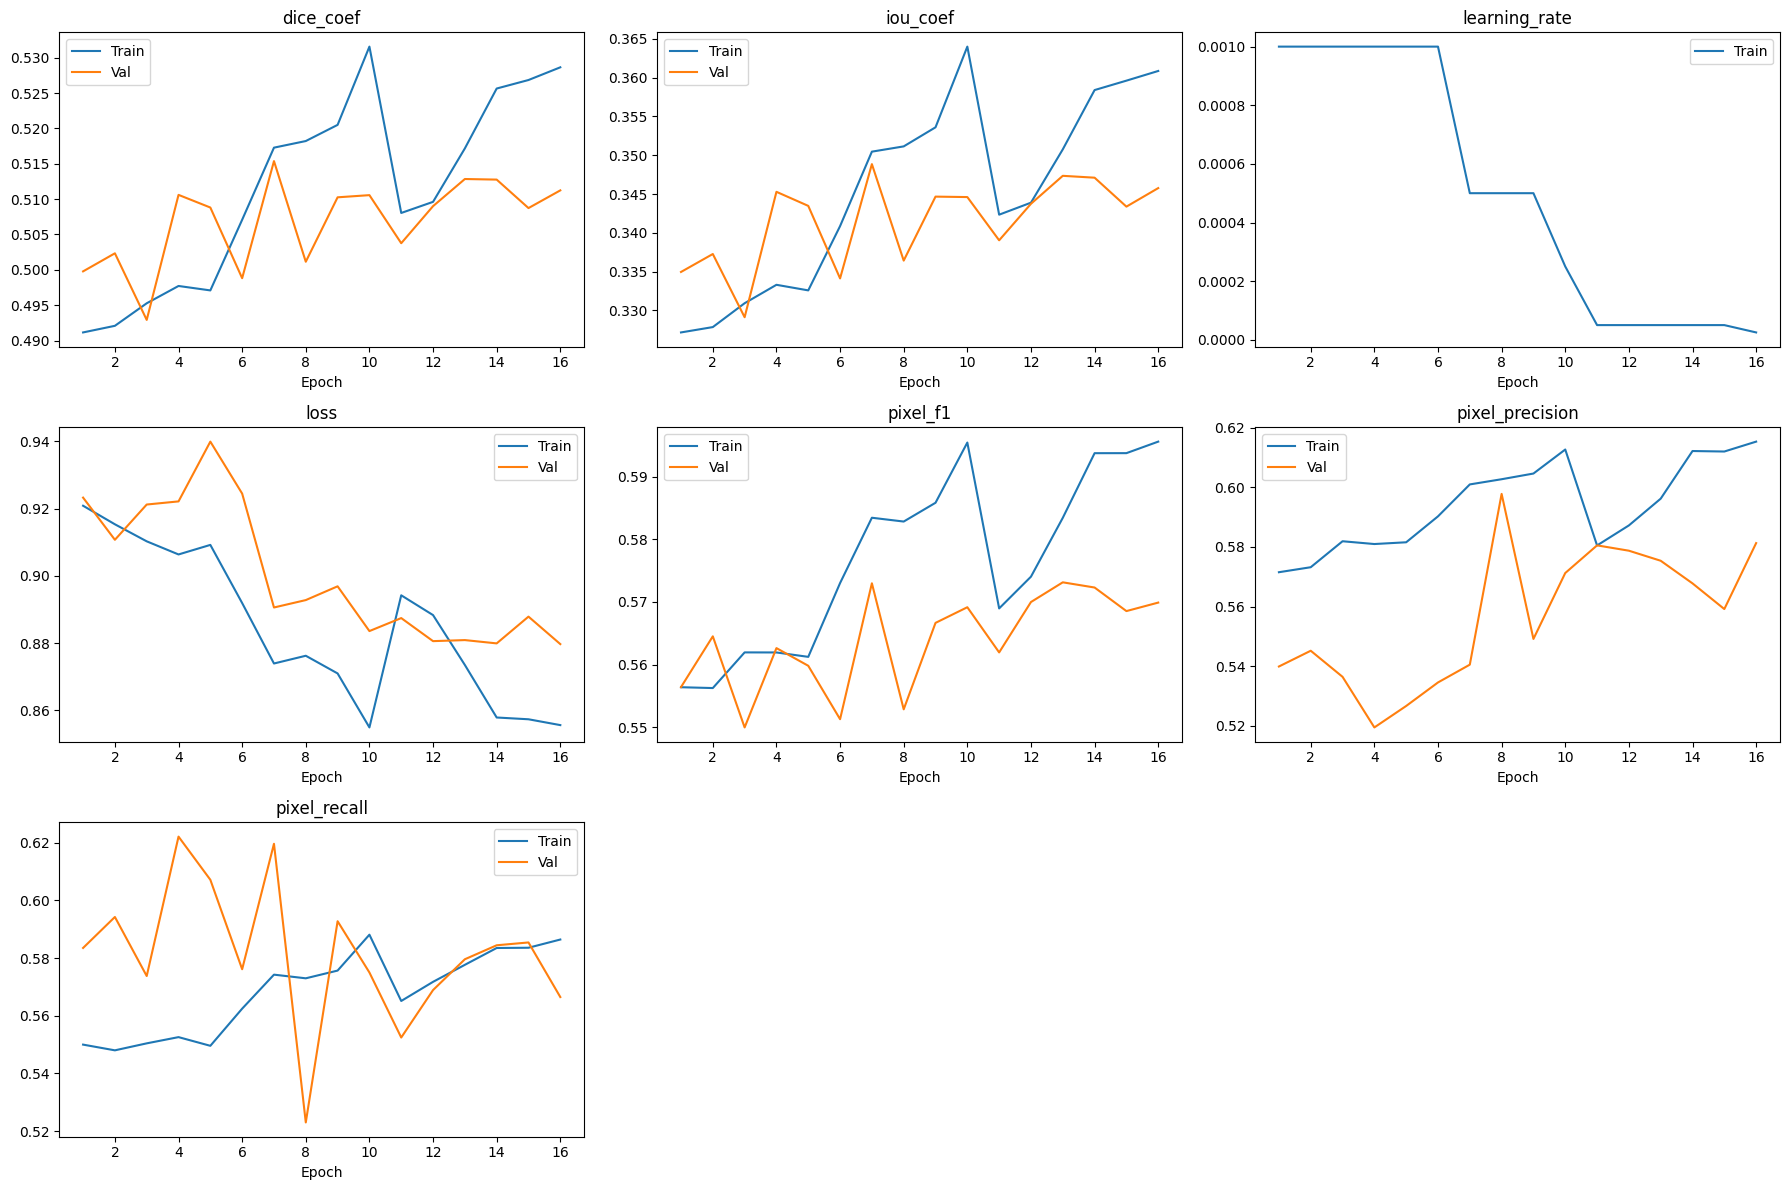

{'model': <Functional name=functional_1, built=True>,
 'history': {'dice_coef': [0.49114465713500977,
   0.49208006262779236,
   0.4952678680419922,
   0.49771493673324585,
   0.4970875084400177,
   0.5070807933807373,
   0.5172777771949768,
   0.5182132720947266,
   0.5204989910125732,
   0.5315667390823364,
   0.508041262626648,
   0.5096114873886108,
   0.5171712040901184,
   0.5256398320198059,
   0.5268440842628479,
   0.5286411046981812],
  'iou_coef': [0.327149897813797,
   0.32783910632133484,
   0.33091625571250916,
   0.33329257369041443,
   0.3325727880001068,
   0.34086185693740845,
   0.3504642844200134,
   0.3511425852775574,
   0.3536035716533661,
   0.3640091121196747,
   0.3423362374305725,
   0.34388402104377747,
   0.35075733065605164,
   0.3584064245223999,
   0.35962051153182983,
   0.3608689606189728],
  'loss': [0.9208409190177917,
   0.9153242707252502,
   0.9102583527565002,
   0.9063577651977539,
   0.9091974496841431,
   0.8919074535369873,
   0.8739343285560

In [7]:
# Paso 6: entrenamiento forzado con ResNet50 y selección del mejor checkpoint
config = PipelineConfig(
    seed=42,
    image_size=224,
    orig_height=1400,
    orig_width=2100,
    batch_size=8,
    epochs_stage1=30,
    epochs_stage2=30,
    max_images=1200,
    fine_tune_last_layers=24,
    learning_rate_stage1=1e-3,
    learning_rate_stage2=5e-5,
    auto_tune=False,
    tuning_trials=3,
    tuning_train_samples=256,
    tuning_val_samples=64,
    evaluation_batches=12,
    object_iou_threshold=0.5,
)


def _evaluate_checkpoint_score(model: Model, checkpoint_path: Path, val_gen: CloudSequence) -> float:
    if not checkpoint_path.exists():
        return -1.0
    model.load_weights(checkpoint_path)
    scores = model.evaluate(val_gen, verbose=0, return_dict=True)
    return float(scores.get("dice_coef", -1.0))


data_root_env = os.getenv("CLOUD_DATA_ROOT")
data_root = Path(data_root_env) if data_root_env else PROJECT_ROOT

try:
    resolve_dataset_paths(data_root)
except FileNotFoundError:
    if os.getenv("DOWNLOAD_DATA", "0") == "1" or os.getenv("KAGGLE_API_TOKEN"):
        data_root = download_competition_data()
    else:
        raise FileNotFoundError(
            "No se encontró el dataset. Define CLOUD_DATA_ROOT o habilita DOWNLOAD_DATA=1 con KAGGLE_API_TOKEN configurado."
        )

set_seed(config.seed)
enable_mixed_precision_if_available()
DEFAULT_ARTIFACTS_DIR.mkdir(parents=True, exist_ok=True)
DEFAULT_CHECKPOINT_DIR.mkdir(parents=True, exist_ok=True)

state_path = DEFAULT_TRAINING_STATE_PATH
save_training_state(state_path, {"stage": "stage1", "stage1_epoch": 0, "stage2_epoch": 0})

train_csv, train_img_dir, mask_df, train_ids, val_ids = build_dataset_splits(data_root, config)
train_gen, val_gen = build_generators(train_ids, val_ids, train_img_dir, mask_df, config)

model, base = build_model(config)
stage1_weights = DEFAULT_CHECKPOINT_DIR / "stage1_best.weights.h5"
stage2_weights = DEFAULT_CHECKPOINT_DIR / "stage2_best.weights.h5"
if stage1_weights.exists():
    model.load_weights(stage1_weights)

compile_model(
    model,
    base,
    fine_tune=False,
    learning_rate=config.learning_rate_stage1,
    fine_tune_last_layers=config.fine_tune_last_layers,
)
stage1_history = model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=config.epochs_stage1,
    callbacks=build_callbacks("stage1", DEFAULT_CHECKPOINT_DIR, DEFAULT_CHECKPOINT_DIR / "backup", state_path),
    verbose=1,
)

compile_model(
    model,
    base,
    fine_tune=True,
    learning_rate=config.learning_rate_stage2,
    fine_tune_last_layers=config.fine_tune_last_layers,
)
stage2_history = model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=config.epochs_stage2,
    callbacks=build_callbacks("stage2", DEFAULT_CHECKPOINT_DIR, DEFAULT_CHECKPOINT_DIR / "backup", state_path),
    verbose=1,
)

stage1_score = _evaluate_checkpoint_score(model, stage1_weights, val_gen)
stage2_score = _evaluate_checkpoint_score(model, stage2_weights, val_gen)
best_checkpoint = stage1_weights if stage1_score >= stage2_score else stage2_weights
if best_checkpoint.exists():
    model.load_weights(best_checkpoint)

history = merge_histories(stage1_history, stage2_history)
thresholds = find_best_thresholds(model, val_gen)
save_thresholds(thresholds)

results = {key: float(value) for key, value in model.evaluate(val_gen, verbose=1, return_dict=True).items()}
detection_metrics = evaluate_object_detection_metrics(
    model,
    val_gen,
    thresholds,
    config,
    max_batches=config.evaluation_batches,
)
results.update(detection_metrics)
results["config"] = asdict(config)
results["selected_checkpoint"] = str(best_checkpoint)
results["stage1_checkpoint_dice"] = float(stage1_score)
results["stage2_checkpoint_dice"] = float(stage2_score)
save_metrics_report(results)
save_model_bundle(model, thresholds=thresholds, config=config, metrics=results, save_keras_compat=True)

state = load_training_state(state_path)
state["stage"] = "done"
state["final_model_path"] = str(DEFAULT_FINAL_MODEL_PKL_PATH)
state["thresholds_path"] = str(DEFAULT_THRESHOLDS_PATH)
state["selected_checkpoint"] = str(best_checkpoint)
save_training_state(state_path, state)

artifacts = {
    "model": model,
    "history": history,
    "thresholds": thresholds,
    "results": results,
    "metrics_report": results,
    "state": state,
    "train_csv": train_csv,
    "train_img_dir": train_img_dir,
}

summary_keys = [
    "loss",
    "dice_coef",
    "iou_coef",
    "pixel_precision",
    "pixel_recall",
    "pixel_f1",
    "det_precision",
    "det_recall",
    "det_f1",
    "det_ap50",
    "det_mean_iou",
    "stage1_checkpoint_dice",
    "stage2_checkpoint_dice",
]
print(json.dumps({key: results[key] for key in summary_keys if key in results}, indent=2))
if history:
    plot_history(history)

artifacts

In [8]:
artifacts = run_pipeline()
artifacts

/system/conda/miniconda3/envs/cloudspace/lib/python3.12/site-packages/albumentations/core/validation.py:114: UserWarning: ShiftScaleRotate is a special case of Affine transform. Please use Affine transform instead.
  original_init(self, **validated_kwargs)


{
  "loss": 0.8905872702598572,
  "dice_coef": 0.5153744220733643,
  "iou_coef": 0.34885531663894653,
  "pixel_precision": 0.5405255556106567,
  "pixel_recall": 0.6196250319480896,
  "pixel_f1": 0.5729827284812927,
  "det_precision": 0.24850678600678602,
  "det_recall": 0.3544620811287478,
  "det_f1": 0.2905054508220952,
  "det_ap50": 0.25655983483413203,
  "det_mean_iou": 0.700778691564422
}


{'model': <Functional name=functional_1, built=True>,
 'history': {},
 'thresholds': [0.45999999999999996, 0.59, 0.41, 0.37],
 'results': {'dice_coef': 0.5153744220733643,
  'iou_coef': 0.34885531663894653,
  'loss': 0.8905872702598572,
  'pixel_f1': 0.5729827284812927,
  'pixel_precision': 0.5405255556106567,
  'pixel_recall': 0.6196250319480896,
  'det_precision_fish': 0.16071428571428573,
  'det_recall_fish': 0.2571428571428571,
  'det_f1_fish': 0.1978021978021978,
  'det_ap50_fish': 0.14769395122744566,
  'det_mean_iou_fish': 0.6503020335989267,
  'det_precision_flower': 0.4189189189189189,
  'det_recall_flower': 0.49206349206349204,
  'det_f1_flower': 0.4525547445255474,
  'det_ap50_flower': 0.39618448851872756,
  'det_mean_iou_flower': 0.7446008509290438,
  'det_precision_gravel': 0.1893939393939394,
  'det_recall_gravel': 0.30864197530864196,
  'det_f1_gravel': 0.2347417840375587,
  'det_ap50_gravel': 0.25231363374115023,
  'det_mean_iou_gravel': 0.7156807144284848,
  'det_preci

## Paso 6b: reentrenamiento rápido

Versión más liviana para terminar en este entorno, reutilizando el checkpoint previo como punto de partida y volviendo a medir métricas.

In [9]:
# Paso 6c: optimizacion de hiperparametros por etapas y entrenamiento final robusto
from itertools import product
import random


@dataclass
class HPOResult:
    config: PipelineConfig
    score: float
    details: dict[str, Any]


BASE_SEARCH_GRID = {
    "image_size": [192, 224],
    "batch_size": [4, 6],
    "max_images": [400, 800, None],
    "fine_tune_last_layers": [24, 40, 64],
    "learning_rate_stage1": [3e-4, 5e-4, 1e-3],
    "learning_rate_stage2": [1e-5, 2e-5, 5e-5],
}


def _iter_grid_candidates(base_config: PipelineConfig, seed: int = 42) -> list[PipelineConfig]:
    rng = random.Random(seed)
    keys = list(BASE_SEARCH_GRID.keys())
    values = [BASE_SEARCH_GRID[key] for key in keys]
    candidates = []

    for combo in product(*values):
        candidate_kwargs = {key: value for key, value in zip(keys, combo)}
        candidate_kwargs.update(
            {
                "seed": base_config.seed,
                "orig_height": base_config.orig_height,
                "orig_width": base_config.orig_width,
                "epochs_stage1": base_config.epochs_stage1,
                "epochs_stage2": base_config.epochs_stage2,
                "auto_tune": False,
                "tuning_trials": base_config.tuning_trials,
                "tuning_train_samples": base_config.tuning_train_samples,
                "tuning_val_samples": base_config.tuning_val_samples,
                "evaluation_batches": base_config.evaluation_batches,
                "object_iou_threshold": base_config.object_iou_threshold,
                "classes": base_config.classes,
            }
        )
        candidates.append(PipelineConfig(**candidate_kwargs))

    rng.shuffle(candidates)
    return candidates


def _build_tuned_generators(data_root: str | Path, config: PipelineConfig) -> tuple[Path, Path, pd.DataFrame, list[str], list[str], CloudSequence, CloudSequence]:
    train_csv, train_img_dir, mask_df, train_ids, val_ids = build_dataset_splits(data_root, config)
    train_ids = train_ids[: min(len(train_ids), config.tuning_train_samples)]
    val_ids = val_ids[: min(len(val_ids), config.tuning_val_samples)]
    train_gen, val_gen = build_generators(train_ids, val_ids, train_img_dir, mask_df, config)
    return train_csv, train_img_dir, mask_df, train_ids, val_ids, train_gen, val_gen


def _train_short_candidate(data_root: str | Path, config: PipelineConfig) -> HPOResult:
    set_seed(config.seed)
    train_csv, train_img_dir, mask_df, train_ids, val_ids, train_gen, val_gen = _build_tuned_generators(data_root, config)

    model, base = build_model(config)
    compile_model(
        model,
        base,
        fine_tune=False,
        learning_rate=config.learning_rate_stage1,
        fine_tune_last_layers=config.fine_tune_last_layers,
    )
    model.fit(
        train_gen,
        validation_data=val_gen,
        epochs=min(2, config.epochs_stage1),
        verbose=0,
        callbacks=[EarlyStopping(monitor="val_dice_coef", mode="max", patience=1, restore_best_weights=True)],
    )
    compile_model(
        model,
        base,
        fine_tune=True,
        learning_rate=config.learning_rate_stage2,
        fine_tune_last_layers=config.fine_tune_last_layers,
    )
    model.fit(
        train_gen,
        validation_data=val_gen,
        epochs=min(1, config.epochs_stage2),
        verbose=0,
        callbacks=[EarlyStopping(monitor="val_dice_coef", mode="max", patience=1, restore_best_weights=True)],
    )

    val_scores = model.evaluate(val_gen, verbose=0, return_dict=True)
    thresholds = find_best_thresholds(model, val_gen)
    det_scores = evaluate_object_detection_metrics(model, val_gen, thresholds, config, max_batches=1)
    score = 0.7 * float(val_scores["dice_coef"]) + 0.3 * float(det_scores.get("det_f1", 0.0))

    return HPOResult(
        config=config,
        score=score,
        details={
            "val_scores": {key: float(value) for key, value in val_scores.items()},
            "det_scores": det_scores,
            "thresholds": thresholds,
            "train_csv": str(train_csv),
            "train_img_dir": str(train_img_dir),
            "train_size": len(train_ids),
            "val_size": len(val_ids),
        },
    )


def optimize_hyperparameters(data_root: str | Path, base_config: Optional[PipelineConfig] = None, max_candidates: int = 12) -> HPOResult:
    base_config = base_config or get_runtime_config()
    candidates = _iter_grid_candidates(base_config)
    candidates = candidates[: max_candidates]
    best_result: Optional[HPOResult] = None
    ranked_results: list[HPOResult] = []

    for index, candidate in enumerate(candidates, start=1):
        result = _train_short_candidate(data_root, candidate)
        ranked_results.append(result)
        print(
            f"Trial {index}/{len(candidates)} | score={result.score:.4f} | "
            f"img={candidate.image_size} batch={candidate.batch_size} "
            f"lr1={candidate.learning_rate_stage1:.1e} lr2={candidate.learning_rate_stage2:.1e} "
            f"ft={candidate.fine_tune_last_layers} max_images={candidate.max_images}"
        )
        if best_result is None or result.score > best_result.score:
            best_result = result

    ranked_results.sort(key=lambda item: item.score, reverse=True)
    best_result = ranked_results[0]

    tuned_config = replace(
        best_result.config,
        epochs_stage1=max(base_config.epochs_stage1, 30),
        epochs_stage2=max(base_config.epochs_stage2, 30),
        max_images=base_config.max_images,
        evaluation_batches=base_config.evaluation_batches,
        tuning_trials=base_config.tuning_trials,
        tuning_train_samples=base_config.tuning_train_samples,
        tuning_val_samples=base_config.tuning_val_samples,
    )

    return HPOResult(
        config=tuned_config,
        score=best_result.score,
        details={
            "top_trials": [
                {
                    "score": item.score,
                    "config": asdict(item.config),
                }
                for item in ranked_results[:3]
            ],
            "best_short_details": best_result.details,
        },
    )


def train_best_model_with_hpo(data_root: str | Path, max_candidates: int = 12, force_retrain: bool = True) -> dict[str, Any]:
    base_config = PipelineConfig(
        seed=42,
        image_size=224,
        orig_height=1400,
        orig_width=2100,
        batch_size=6,
        epochs_stage1=30,
        epochs_stage2=30,
        max_images=None,
        fine_tune_last_layers=48,
        learning_rate_stage1=5e-4,
        learning_rate_stage2=1e-5,
        auto_tune=False,
        tuning_trials=12,
        tuning_train_samples=256,
        tuning_val_samples=64,
        evaluation_batches=None,
        object_iou_threshold=0.5,
    )

    hpo_result = optimize_hyperparameters(data_root, base_config=base_config, max_candidates=max_candidates)
    tuned_config = hpo_result.config

    set_seed(tuned_config.seed)
    enable_mixed_precision_if_available()
    DEFAULT_ARTIFACTS_DIR.mkdir(parents=True, exist_ok=True)
    DEFAULT_CHECKPOINT_DIR.mkdir(parents=True, exist_ok=True)

    state_path = DEFAULT_TRAINING_STATE_PATH
    if force_retrain:
        save_training_state(state_path, {"stage": "stage1", "stage1_epoch": 0, "stage2_epoch": 0})

    train_csv, train_img_dir, mask_df, train_ids, val_ids = build_dataset_splits(data_root, tuned_config)
    train_gen, val_gen = build_generators(train_ids, val_ids, train_img_dir, mask_df, tuned_config)

    model, base = build_model(tuned_config)
    stage1_weights = DEFAULT_CHECKPOINT_DIR / "stage1_best.weights.h5"
    stage2_weights = DEFAULT_CHECKPOINT_DIR / "stage2_best.weights.h5"
    if stage1_weights.exists() and not force_retrain:
        model.load_weights(stage1_weights)

    compile_model(
        model,
        base,
        fine_tune=False,
        learning_rate=tuned_config.learning_rate_stage1,
        fine_tune_last_layers=tuned_config.fine_tune_last_layers,
    )
    stage1_history = model.fit(
        train_gen,
        validation_data=val_gen,
        epochs=tuned_config.epochs_stage1,
        callbacks=build_callbacks("stage1", DEFAULT_CHECKPOINT_DIR, DEFAULT_CHECKPOINT_DIR / "backup", state_path),
        verbose=1,
    )

    compile_model(
        model,
        base,
        fine_tune=True,
        learning_rate=tuned_config.learning_rate_stage2,
        fine_tune_last_layers=tuned_config.fine_tune_last_layers,
    )
    stage2_history = model.fit(
        train_gen,
        validation_data=val_gen,
        epochs=tuned_config.epochs_stage2,
        callbacks=build_callbacks("stage2", DEFAULT_CHECKPOINT_DIR, DEFAULT_CHECKPOINT_DIR / "backup", state_path),
        verbose=1,
    )

    stage1_score = _evaluate_checkpoint_score(model, stage1_weights, val_gen)
    stage2_score = _evaluate_checkpoint_score(model, stage2_weights, val_gen)
    best_checkpoint = stage1_weights if stage1_score >= stage2_score else stage2_weights
    if best_checkpoint.exists():
        model.load_weights(best_checkpoint)

    history = merge_histories(stage1_history, stage2_history)
    thresholds = find_best_thresholds(model, val_gen)
    save_thresholds(thresholds)

    results = {key: float(value) for key, value in model.evaluate(val_gen, verbose=1, return_dict=True).items()}
    detection_metrics = evaluate_object_detection_metrics(
        model,
        val_gen,
        thresholds,
        tuned_config,
        max_batches=tuned_config.evaluation_batches,
    )
    results.update(detection_metrics)
    results["config"] = asdict(tuned_config)
    results["hpo_score"] = float(hpo_result.score)
    results["selected_checkpoint"] = str(best_checkpoint)
    results["stage1_checkpoint_dice"] = float(stage1_score)
    results["stage2_checkpoint_dice"] = float(stage2_score)
    save_metrics_report(results)
    save_model_bundle(model, thresholds=thresholds, config=tuned_config, metrics=results, save_keras_compat=True)

    state = load_training_state(state_path)
    state["stage"] = "done"
    state["final_model_path"] = str(DEFAULT_FINAL_MODEL_PKL_PATH)
    state["thresholds_path"] = str(DEFAULT_THRESHOLDS_PATH)
    state["selected_checkpoint"] = str(best_checkpoint)
    state["hpo_score"] = float(hpo_result.score)
    save_training_state(state_path, state)

    artifacts = {
        "model": model,
        "history": history,
        "thresholds": thresholds,
        "results": results,
        "metrics_report": results,
        "state": state,
        "train_csv": train_csv,
        "train_img_dir": train_img_dir,
        "hpo_result": hpo_result.details,
    }

    print(json.dumps({
        "hpo_score": hpo_result.score,
        "dice_coef": results.get("dice_coef"),
        "iou_coef": results.get("iou_coef"),
        "pixel_f1": results.get("pixel_f1"),
        "det_f1": results.get("det_f1"),
        "det_ap50": results.get("det_ap50"),
    }, indent=2))
    if history:
        plot_history(history)

    return artifacts

/system/conda/miniconda3/envs/cloudspace/lib/python3.12/site-packages/albumentations/core/validation.py:114: UserWarning: ShiftScaleRotate is a special case of Affine transform. Please use Affine transform instead.
  original_init(self, **validated_kwargs)
/system/conda/miniconda3/envs/cloudspace/lib/python3.12/site-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/30
 4/20 ━━━━━━━━━━━━━━━━━━━━ 56s 4s/step - dice_coef: 0.5135 - iou_coef: 0.3457 - loss: 0.8689 - pixel_f1: 0.5754 - pixel_precision: 0.5628 - pixel_recall: 0.5917 

20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 4s/step - dice_coef: 0.5142 - iou_coef: 0.3477 - loss: 0.8668 - pixel_f1: 0.5765 - pixel_precision: 0.5776 - pixel_recall: 0.5805
Epoch 1: val_dice_coef improved from None to 0.53971, saving model to /teamspace/studios/this_studio/models/checkpoints/stage1_best.weights.h5

Epoch 1: finished saving model to /teamspace/studios/this_studio/models/checkpoints/stage1_best.weights.h5
20/20 ━━━━━━━━━━━━━━━━━━━━ 99s 4s/step - dice_coef: 0.5171 - iou_coef: 0.3507 - loss: 0.8695 - pixel_f1: 0.5802 - pixel_precision: 0.6038 - pixel_recall: 0.5666 - val_dice_coef: 0.5397 - val_iou_coef: 0.3707 - val_loss: 0.8744 - val_pixel_f1: 0.5898 - val_pixel_precision: 0.6177 - val_pixel_recall: 0.5684 - learning_rate: 0.0010
Epoch 2/30
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 4s/step - dice_coef: 0.5131 - iou_coef: 0.3474 - loss: 0.8736 - pixel_f1: 0.5762 - pixel_precision: 0.5806 - pixel_recall: 0.5797
Epoch 2: val_dice_coef did not improve from 0.53971
20/20 ━━━━━━━━━━━━━━━━━━━━ 81s 4s/s

/system/conda/miniconda3/envs/cloudspace/lib/python3.12/site-packages/keras/src/saving/saving_lib.py:798: UserWarning: Skipping variable loading for optimizer 'adam', because it has 122 variables whereas the saved optimizer has 86 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


5/5 ━━━━━━━━━━━━━━━━━━━━ 7s 1s/step - dice_coef: 0.5608 - iou_coef: 0.3904 - loss: 0.8385 - pixel_f1: 0.6222 - pixel_precision: 0.6852 - pixel_recall: 0.5737
{
  "loss": 0.8385171890258789,
  "dice_coef": 0.5608281493186951,
  "iou_coef": 0.39040660858154297,
  "pixel_precision": 0.68517005443573,
  "pixel_recall": 0.5737058520317078,
  "pixel_f1": 0.622235119342804,
  "det_precision": 0.4095248633963186,
  "det_recall": 0.498605812923654,
  "det_f1": 0.44802094750943855,
  "det_ap50": 0.4367386454105493,
  "det_mean_iou": 0.6963167204845659,
  "stage1_checkpoint_dice": 0.5608281493186951,
  "stage2_checkpoint_dice": 0.5594016313552856
}


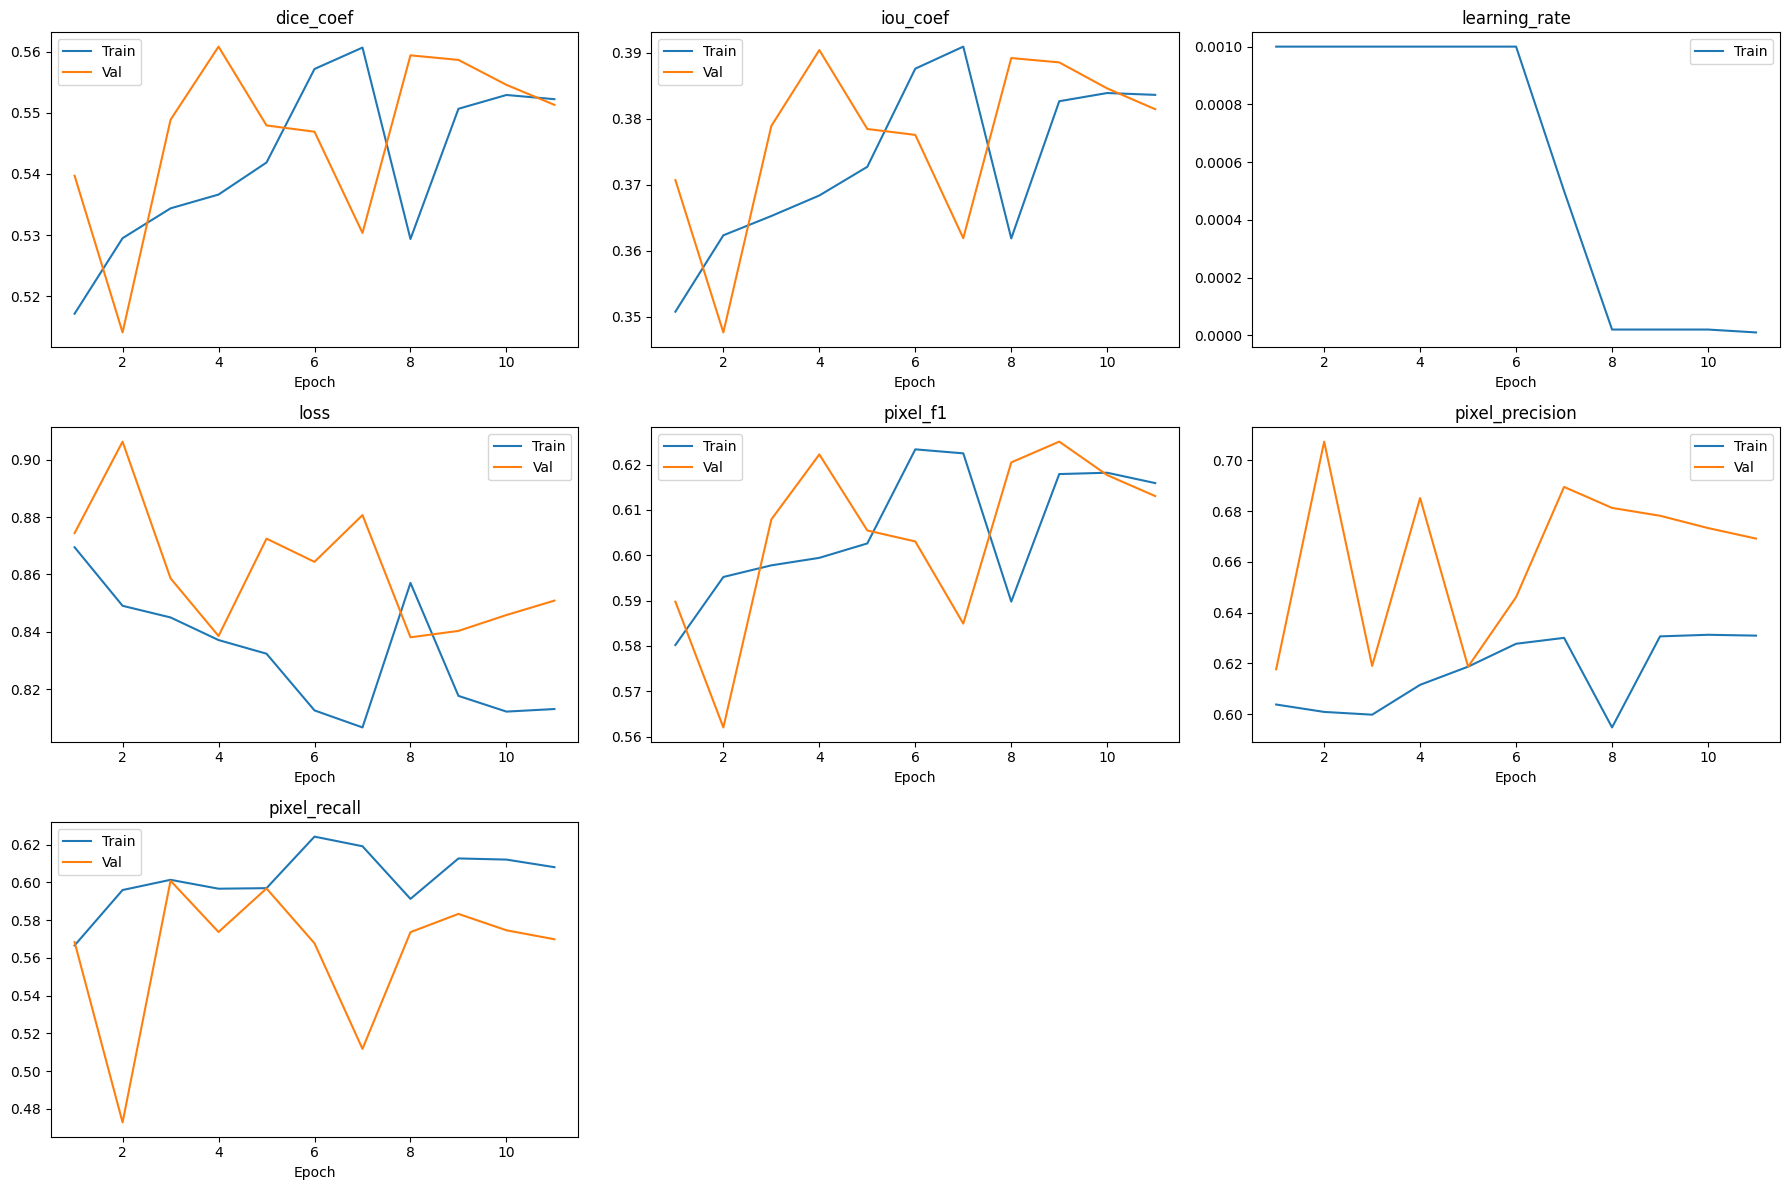

{'model': <Functional name=functional_3, built=True>,
 'history': {'dice_coef': [0.51713627576828,
   0.5294929146766663,
   0.5343756079673767,
   0.5366308093070984,
   0.5418710708618164,
   0.5571718215942383,
   0.5606721043586731,
   0.5293623208999634,
   0.5506606698036194,
   0.5529165863990784,
   0.5522316694259644],
  'iou_coef': [0.3507394790649414,
   0.3623196482658386,
   0.36524611711502075,
   0.36835652589797974,
   0.3727053999900818,
   0.38758596777915955,
   0.3909263610839844,
   0.36184918880462646,
   0.3826472759246826,
   0.38389158248901367,
   0.383613258600235],
  'loss': [0.8694702982902527,
   0.8490514755249023,
   0.8449873924255371,
   0.8371008634567261,
   0.8323378562927246,
   0.8125576972961426,
   0.8066233396530151,
   0.8570334315299988,
   0.8176287412643433,
   0.8121453523635864,
   0.8130423426628113],
  'pixel_f1': [0.5801967978477478,
   0.5952072143554688,
   0.5977737903594971,
   0.5994276404380798,
   0.6026049852371216,
   0.623355

In [10]:
# Paso 6b: entrenamiento rápido con ResNet50
config = PipelineConfig(
    seed=42,
    image_size=192,
    orig_height=1400,
    orig_width=2100,
    batch_size=8,
    epochs_stage1=30,
    epochs_stage2=30,
    max_images=200,
    fine_tune_last_layers=16,
    learning_rate_stage1=1e-3,
    learning_rate_stage2=2e-5,
    auto_tune=False,
    tuning_trials=3,
    tuning_train_samples=256,
    tuning_val_samples=64,
    evaluation_batches=12,
    object_iou_threshold=0.5,
)


def _evaluate_checkpoint_score_fast(model: Model, checkpoint_path: Path, val_gen: CloudSequence) -> float:
    if not checkpoint_path.exists():
        return -1.0
    model.load_weights(checkpoint_path)
    scores = model.evaluate(val_gen, verbose=0, return_dict=True)
    return float(scores.get("dice_coef", -1.0))


data_root_env = os.getenv("CLOUD_DATA_ROOT")
data_root = Path(data_root_env) if data_root_env else PROJECT_ROOT

try:
    resolve_dataset_paths(data_root)
except FileNotFoundError:
    if os.getenv("DOWNLOAD_DATA", "0") == "1" or os.getenv("KAGGLE_API_TOKEN"):
        data_root = download_competition_data()
    else:
        raise FileNotFoundError(
            "No se encontró el dataset. Define CLOUD_DATA_ROOT o habilita DOWNLOAD_DATA=1 con KAGGLE_API_TOKEN configurado."
        )

set_seed(config.seed)
enable_mixed_precision_if_available()
DEFAULT_ARTIFACTS_DIR.mkdir(parents=True, exist_ok=True)
DEFAULT_CHECKPOINT_DIR.mkdir(parents=True, exist_ok=True)

state_path = DEFAULT_TRAINING_STATE_PATH
save_training_state(state_path, {"stage": "stage1", "stage1_epoch": 0, "stage2_epoch": 0})

train_csv, train_img_dir, mask_df, train_ids, val_ids = build_dataset_splits(data_root, config)
train_gen, val_gen = build_generators(train_ids, val_ids, train_img_dir, mask_df, config)

model, base = build_model(config)
stage1_weights = DEFAULT_CHECKPOINT_DIR / "stage1_best.weights.h5"
stage2_weights = DEFAULT_CHECKPOINT_DIR / "stage2_best.weights.h5"
if stage1_weights.exists():
    model.load_weights(stage1_weights)

compile_model(
    model,
    base,
    fine_tune=False,
    learning_rate=config.learning_rate_stage1,
    fine_tune_last_layers=config.fine_tune_last_layers,
)
stage1_history = model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=config.epochs_stage1,
    callbacks=build_callbacks("stage1", DEFAULT_CHECKPOINT_DIR, DEFAULT_CHECKPOINT_DIR / "backup", state_path),
    verbose=1,
)

compile_model(
    model,
    base,
    fine_tune=True,
    learning_rate=config.learning_rate_stage2,
    fine_tune_last_layers=config.fine_tune_last_layers,
)
stage2_history = model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=config.epochs_stage2,
    callbacks=build_callbacks("stage2", DEFAULT_CHECKPOINT_DIR, DEFAULT_CHECKPOINT_DIR / "backup", state_path),
    verbose=1,
)

stage1_score = _evaluate_checkpoint_score_fast(model, stage1_weights, val_gen)
stage2_score = _evaluate_checkpoint_score_fast(model, stage2_weights, val_gen)
best_checkpoint = stage1_weights if stage1_score >= stage2_score else stage2_weights
if best_checkpoint.exists():
    model.load_weights(best_checkpoint)

history = merge_histories(stage1_history, stage2_history)
thresholds = find_best_thresholds(model, val_gen)
save_thresholds(thresholds)

results = {key: float(value) for key, value in model.evaluate(val_gen, verbose=1, return_dict=True).items()}
detection_metrics = evaluate_object_detection_metrics(
    model,
    val_gen,
    thresholds,
    config,
    max_batches=config.evaluation_batches,
)
results.update(detection_metrics)
results["config"] = asdict(config)
results["selected_checkpoint"] = str(best_checkpoint)
results["stage1_checkpoint_dice"] = float(stage1_score)
results["stage2_checkpoint_dice"] = float(stage2_score)
save_metrics_report(results)
save_model_bundle(model, thresholds=thresholds, config=config, metrics=results, save_keras_compat=True)

state = load_training_state(state_path)
state["stage"] = "done"
state["final_model_path"] = str(DEFAULT_FINAL_MODEL_PKL_PATH)
state["thresholds_path"] = str(DEFAULT_THRESHOLDS_PATH)
state["selected_checkpoint"] = str(best_checkpoint)
save_training_state(state_path, state)

artifacts = {
    "model": model,
    "history": history,
    "thresholds": thresholds,
    "results": results,
    "metrics_report": results,
    "state": state,
    "train_csv": train_csv,
    "train_img_dir": train_img_dir,
}

summary_keys = [
    "loss",
    "dice_coef",
    "iou_coef",
    "pixel_precision",
    "pixel_recall",
    "pixel_f1",
    "det_precision",
    "det_recall",
    "det_f1",
    "det_ap50",
    "det_mean_iou",
    "stage1_checkpoint_dice",
    "stage2_checkpoint_dice",
]
print(json.dumps({key: results[key] for key in summary_keys if key in results}, indent=2))
if history:
    plot_history(history)

artifacts

## Paso 6d: ejecución final con optimización

Ejecuta esta sección cuando quieras correr la búsqueda de hiperparámetros y el reentrenamiento largo con la mejor configuración encontrada.

In [ ]:
# Ejecuta la busqueda y el reentrenamiento final robusto cuando quieras correr la version completa.
artifacts = train_best_model_with_hpo(data_root=PROJECT_ROOT, max_candidates=12, force_retrain=True)
artifacts

/system/conda/miniconda3/envs/cloudspace/lib/python3.12/site-packages/albumentations/core/validation.py:114: UserWarning: ShiftScaleRotate is a special case of Affine transform. Please use Affine transform instead.
  original_init(self, **validated_kwargs)
/system/conda/miniconda3/envs/cloudspace/lib/python3.12/site-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Trial 1/12 | score=0.2791 | img=224 batch=4 lr1=5.0e-04 lr2=5.0e-05 ft=40 max_images=None


/system/conda/miniconda3/envs/cloudspace/lib/python3.12/site-packages/albumentations/core/validation.py:114: UserWarning: ShiftScaleRotate is a special case of Affine transform. Please use Affine transform instead.
  original_init(self, **validated_kwargs)
/system/conda/miniconda3/envs/cloudspace/lib/python3.12/site-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Trial 2/12 | score=0.2381 | img=192 batch=6 lr1=3.0e-04 lr2=5.0e-05 ft=40 max_images=None


/system/conda/miniconda3/envs/cloudspace/lib/python3.12/site-packages/albumentations/core/validation.py:114: UserWarning: ShiftScaleRotate is a special case of Affine transform. Please use Affine transform instead.
  original_init(self, **validated_kwargs)
/system/conda/miniconda3/envs/cloudspace/lib/python3.12/site-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


...

Trial 11/12 | score=0.3486 | img=192 batch=4 lr1=1.0e-03 lr2=1.0e-05 ft=24 max_images=800


/system/conda/miniconda3/envs/cloudspace/lib/python3.12/site-packages/albumentations/core/validation.py:114: UserWarning: ShiftScaleRotate is a special case of Affine transform. Please use Affine transform instead.
  original_init(self, **validated_kwargs)
/system/conda/miniconda3/envs/cloudspace/lib/python3.12/site-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Trial 12/12 | score=0.3455 | img=224 batch=4 lr1=1.0e-03 lr2=2.0e-05 ft=40 max_images=800


/system/conda/miniconda3/envs/cloudspace/lib/python3.12/site-packages/albumentations/core/validation.py:114: UserWarning: ShiftScaleRotate is a special case of Affine transform. Please use Affine transform instead.
  original_init(self, **validated_kwargs)
/system/conda/miniconda3/envs/cloudspace/lib/python3.12/site-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/30
1109/1109 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - dice_coef: 0.3397 - iou_coef: 0.2070 - loss: 1.1655 - pixel_f1: 0.4250 - pixel_precision: 0.4105 - pixel_recall: 0.4870
Epoch 1: val_dice_coef improved from None to 0.47899, saving model to /teamspace/studios/this_studio/models/checkpoints/stage1_best.weights.h5

Epoch 1: finished saving model to /teamspace/studios/this_studio/models/checkpoints/stage1_best.weights.h5
1109/1109 ━━━━━━━━━━━━━━━━━━━━ 2354s 2s/step - dice_coef: 0.3768 - iou_coef: 0.2345 - loss: 1.0762 - pixel_f1: 0.4556 - pixel_precision: 0.4633 - pixel_recall: 0.4701 - val_dice_coef: 0.4790 - val_iou_coef: 0.3191 - val_loss: 1.0147 - val_pixel_f1: 0.5210 - val_pixel_precision: 0.4768 - val_pixel_recall: 0.5920 - learning_rate: 0.0010
Epoch 2/30
1109/1109 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - dice_coef: 0.4154 - iou_coef: 0.2643 - loss: 1.0143 - pixel_f1: 0.4835 - pixel_precision: 0.4993 - pixel_recall: 0.4822
Epoch 2: val_dice_coef did not improve from 0.47899
1109/1109 

In [ ]:
from pathlib import Path
import json

import cv2
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import tensorflow as tf
from sklearn.model_selection import train_test_split
from tensorflow.keras.models import load_model
from tensorflow.keras.applications.resnet50 import preprocess_input

PROJECT_ROOT = Path.cwd()
DATA_ROOT = PROJECT_ROOT / ".cache/kagglehub/competitions/understanding_cloud_organization"
MODEL_PATH = PROJECT_ROOT / "best_resnet50_cloud_segmentation.keras"
THRESHOLDS_PATH = PROJECT_ROOT / "models/best_thresholds.json"

CLASSES = ("Fish", "Flower", "Gravel", "Sugar")
COLORS = np.array(
    [
        [255, 80, 80],
        [80, 220, 120],
        [80, 140, 255],
        [255, 210, 80],
    ],
    dtype=np.uint8,
)


class DemoConfig:
    seed = 42
    image_size = 192
    orig_height = 1400
    orig_width = 2100
    max_images = 200
    classes = CLASSES


config = DemoConfig()


def resolve_dataset_paths(root: Path) -> tuple[Path, Path]:
    train_csv = root / "train.csv"
    train_img_dir = root / "train_images"
    if train_csv.exists() and train_img_dir.exists():
        return train_csv, train_img_dir
    raise FileNotFoundError(f"No se encontró el dataset en {root}")


def load_annotations(train_csv: Path, classes: tuple[str, ...]) -> pd.DataFrame:
    df = pd.read_csv(train_csv)
    df[["ImageId", "Class"]] = df["Image_Label"].str.rsplit("_", n=1, expand=True)
    mask_df = df.pivot(index="ImageId", columns="Class", values="EncodedPixels")
    return mask_df.reindex(columns=list(classes))


def rle_decode(mask_rle, shape: tuple[int, int]) -> np.ndarray:
    if pd.isna(mask_rle):
        return np.zeros(shape, dtype=np.uint8)
    parts = str(mask_rle).split()
    starts = np.asarray(parts[0::2], dtype=np.int64) - 1
    lengths = np.asarray(parts[1::2], dtype=np.int64)
    ends = starts + lengths
    mask = np.zeros(shape[0] * shape[1], dtype=np.uint8)
    for start, end in zip(starts, ends):
        mask[start:end] = 1
    return mask.reshape((shape[1], shape[0])).T


def load_mask(image_id: str, mask_df: pd.DataFrame, image_size: int) -> np.ndarray:
    mask = np.zeros((config.orig_height, config.orig_width, len(config.classes)), dtype=np.uint8)
    for index, cls in enumerate(config.classes):
        encoded_pixels = mask_df.loc[image_id, cls]
        if isinstance(encoded_pixels, str):
            mask[:, :, index] = rle_decode(encoded_pixels, (config.orig_height, config.orig_width))
    return cv2.resize(mask, (image_size, image_size), interpolation=cv2.INTER_NEAREST)


def load_image(image_path: Path, image_size: int) -> np.ndarray:
    image = cv2.imread(str(image_path))
    if image is None:
        raise FileNotFoundError(f"No se pudo leer la imagen: {image_path}")
    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
    return cv2.resize(image, (image_size, image_size))


def normalize_image_ids(image_ids: list[str], seed: int, max_images: int | None) -> list[str]:
    ids = np.array(image_ids)
    rng = np.random.default_rng(seed)
    rng.shuffle(ids)
    if max_images is not None:
        ids = ids[:max_images]
    return ids.tolist()


def colorize_mask(mask: np.ndarray) -> np.ndarray:
    labeled = np.argmax(mask, axis=-1)
    presence = mask.sum(axis=-1) > 0
    colored = np.zeros((*mask.shape[:2], 3), dtype=np.uint8)
    for class_index, color in enumerate(COLORS):
        colored[(labeled == class_index) & presence] = color
    return colored


def overlay_image(image: np.ndarray, mask: np.ndarray, alpha: float = 0.45) -> np.ndarray:
    mask_rgb = colorize_mask(mask)
    return np.clip((1 - alpha) * image + alpha * mask_rgb, 0, 255).astype(np.uint8)


if not MODEL_PATH.exists():
    raise FileNotFoundError(f"No se encontró el modelo entrenado en {MODEL_PATH}")
if not THRESHOLDS_PATH.exists():
    raise FileNotFoundError(f"No se encontraron los thresholds en {THRESHOLDS_PATH}")

train_csv, train_img_dir = resolve_dataset_paths(DATA_ROOT)
mask_df = load_annotations(train_csv, CLASSES)
image_ids = normalize_image_ids(mask_df.index.tolist(), config.seed, config.max_images)
train_ids, val_ids = train_test_split(image_ids, test_size=0.2, random_state=config.seed)
thresholds = [float(value) for value in json.loads(THRESHOLDS_PATH.read_text())]
model = load_model(MODEL_PATH, compile=False)

sample_scores = []
for image_id in val_ids:
    expected = load_mask(image_id, mask_df, config.image_size)
    sample_scores.append((expected.sum(), image_id))

sample_scores.sort(reverse=True)
sample_ids = [image_id for _, image_id in sample_scores[:4]]

fig, axes = plt.subplots(len(sample_ids), 3, figsize=(15, 5 * len(sample_ids)))
if len(sample_ids) == 1:
    axes = np.expand_dims(axes, axis=0)

for row_index, image_id in enumerate(sample_ids):
    image_path = train_img_dir / image_id
    image = load_image(image_path, config.image_size)
    expected = load_mask(image_id, mask_df, config.image_size)
    x = preprocess_input(image.astype(np.float32))[None, ...]
    prediction = model.predict(x, verbose=0)[0]
    predicted = (prediction > np.array(thresholds)[None, None, :]).astype(np.uint8)

    expected_present = [cls for cls, idx in zip(CLASSES, range(len(CLASSES))) if expected[:, :, idx].sum() > 0]
    predicted_present = [cls for cls, idx in zip(CLASSES, range(len(CLASSES))) if predicted[:, :, idx].sum() > 0]

    axes[row_index, 0].imshow(image)
    axes[row_index, 0].set_title(f"Imagen\n{image_id}")
    axes[row_index, 0].axis("off")

    axes[row_index, 1].imshow(overlay_image(image, expected))
    axes[row_index, 1].set_title("Esperado\n" + (", ".join(expected_present) if expected_present else "sin nube"))
    axes[row_index, 1].axis("off")

    axes[row_index, 2].imshow(overlay_image(image, predicted))
    axes[row_index, 2].set_title("Predicho\n" + (", ".join(predicted_present) if predicted_present else "sin nube"))
    axes[row_index, 2].axis("off")

plt.tight_layout()
plt.show()

print("Modelo cargado:", MODEL_PATH.name)
print("Thresholds:", thresholds)
print("Imágenes mostradas:", sample_ids)


In [ ]:
## Algoritmo de Segmentación de Nubes con ResNet50

### ¿Qué hace el algoritmo?

Este algoritmo realiza **segmentación semántica de nubes** en imágenes satelitales para clasificar píxeles en cuatro categorías:
- **Fish**: Formaciones de nubes en forma de pez
- **Flower**: Formaciones de nubes en forma de flor
- **Gravel**: Formaciones de nubes tipo grava
- **Sugar**: Formaciones de nubes tipo azúcar

Cada píxel se clasifica independientemente, generando máscaras binarias por clase que permiten identificar dónde y qué tipo de nube está presente.

### ¿Cómo funciona?

#### 1. **Arquitectura del Modelo**
- **Base**: ResNet50 preentrenado en ImageNet (extrae características visuales generales)
- **Decodificador**: Capas de upsampling que reconstruyen la resolución original
- **Conexiones skip**: Concatenan características de diferentes niveles de la red para preservar detalles finos
- **Salida**: 4 canales con probabilidades por clase (sigmoid) para segmentación multi-clase independiente

#### 2. **Preprocesamiento**
- Redimensionamiento a 224×224 píxeles (configurable)
- Normalización con `preprocess_input` de ResNet50
- Augmentación de datos: rotaciones, flips, cambios de brillo/contraste
- Decodificación de máscaras desde formato RLE (Run-Length Encoding)

#### 3. **Función de Pérdida**
- **Focal Tversky Loss**: Penaliza falsos negativos y falsos positivos de forma balanceada
- **Binary Cross-Entropy**: Complementa la pérdida focal para mejor convergencia
- **Combinada**: 70% Tversky + 30% BCE

#### 4. **Entrenamiento en Dos Etapas**

**Etapa 1 (Feature Extraction)**
- ResNet50 congelado, solo entrena el decodificador
- Learning rate alto (1e-3): aprendizaje rápido
- ~30 épocas

**Etapa 2 (Fine-tuning)**
- ResNet50 desbloqueado parcialmente (últimas 24-48 capas)
- Learning rate bajo (5e-5): ajustes finos sin destruir características
- ~30 épocas
- Callbacks: Early stopping, reducción de LR, checkpoint automático

### Técnicas para Mejorar Resultados

#### 1. **Búsqueda de Hiperparámetros (HPO)**
- Grid search sobre: tamaño de imagen, batch size, learning rates, capas de fine-tuning
- Entrenamiento corto (2 épocas) para evaluar candidatos rápidamente
- Selecciona mejor configuración antes del entrenamiento final

#### 2. **Optimización de Thresholds**
- Para cada clase, busca el threshold óptimo en validación (0.3-0.7)
- Maximiza Dice coefficient por clase individualmente
- Thresholds guardados e independientes por clase

#### 3. **Selección de Mejor Checkpoint**
- Compara Dice coefficient entre stage1 y stage2
- Carga el checkpoint con mejor desempeño antes de evaluación final
- Evita sobreentrenamiento en stage2

#### 4. **Recuperación de Entrenamiento (Backup & Restore)**
- Guarda estado de entrenamiento cada época
- Permite reanudar desde punto anterior si falla
- Persiste logs de entrenamiento

#### 5. **Métricas Segmentación a Nivel de Píxel**
- **Dice Coefficient**: Medida principal, penaliza falsos negativos
- **IoU (Intersection over Union)**: Overlap entre predicción y verdad
- **Precision/Recall/F1**: Métricas estándar por umbral

### Métricas de Evaluación

#### Segmentación (Píxel)